### TokaMaker Example: Equilibrium reconstruction in DIII-D with Scape-Off Layer Current {#doc_tMaker_DIIID_ex4}
==========
In this example we show how to perform an equilibrium reconstruction in DIII-D using real data from a gEQDSK file, a k-file and a MHDIn.dat file. We also utilize the scrape-off layer functionality to model current outside the LCFS.

**Warning:** The reconstruction functionality in TokaMaker is still a work in progress, as the PSI-Tri capabilities are activated and tested. Please use with care.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a [python wrapper](https://pypi.org/project/triangle/).

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
print(tokamaker_python_path)
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.reconstruction import reconstruction
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk, read_mhdin, read_kfile

/Users/johnl/Desktop/OpenFUSIONToolkit-SOL-Currents


## Initialize TokaMaker object
We now create a \ref OpenFUSIONToolkit.OFT_env "OFT_env" instance for execution using two threads and a \ref OpenFUSIONToolkit.TokaMaker.TokaMaker "TokaMaker" instance to use for equilibrium calculations. Note at present only a single `TokaMaker` instance can be used per python kernel, so this command should only be called **once** in a given Jupyter notebook or python script. In the future this restriction may be relaxed.

In [3]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    Add-FSOL
Revision id:           ff4940ca
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



## Load Info from gEQDSK File and MHDIn.Dat


In [4]:
shot_tag = '199377.02500'

eqdsk = read_eqdsk('g'+shot_tag)
# https://iopscience.iop.org/article/10.1088/1361-6587/ade6a8/pdf

e_coil_names = ['ECOILA','ECOILB','E567UP','E567DN','E89DN','E89UP']
f_coil_names = ['F1A', 'F2A', 'F3A', 'F4A', 'F5A', 'F6A', 'F7A', 'F8A', 'F9A', 'F1B', 'F2B', 'F3B', 'F4B', 'F5B', 'F6B', 'F7B', 'F8B', 'F9B']

machine_dict, _ = read_mhdin('mhdin040324.dat', e_coil_names, f_coil_names)

### Setup Mesh

In [5]:
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('DIIID_mesh_199377.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order = 2, F0 = eqdsk['rcentr']*eqdsk['bcentr'])


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    9190
    # of edges   =   27407
    # of cells   =   18218
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  3.159E-04
    hrms =  4.752E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1779


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    2.6860000000000000E-003
Creating EQ object


## Define vertical stability coils

In [6]:
vsc_signs = {key: 0 for key in mygs.coil_sets}
vsc_signs['F9A'] = 1.0
vsc_signs['F9B'] = -1.0
mygs.set_coil_vsc(vsc_signs)

## Perform Reconstruction

### Create Reconstruction Object

### Load Sensor Locations From Files

In [7]:
mag_sensors = machine_dict['PROBE']
flux_loops = machine_dict['LOOP']

### Plot probe locations

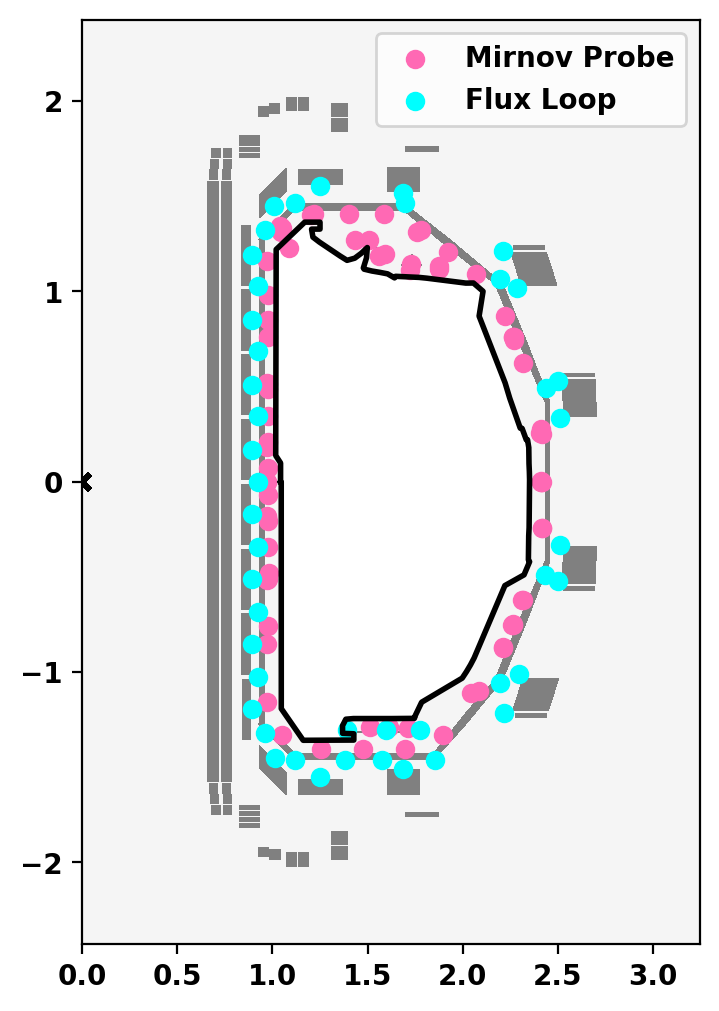

In [8]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,limiter_color='k')
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_constraints(fig, ax)

def plot_sensors(sensors, label, color):
    r_coords = [s[0] for _,s in sensors.items()]
    z_coords = [s[1] for _,s in sensors.items()]
    ax.scatter(x=r_coords, y=z_coords, label=label, color=color)

plot_sensors(mag_sensors, label="Mirnov Probe", color='hotpink')
plot_sensors(flux_loops, label="Flux Loop", color='cyan')

ax.legend()
plt.show()

### Load Shot Data from DIII-D
Here we load data from a DIII-D k file representing a shot at a given point in time.

In [9]:
probes_dict, loops_dict, e_coil_dict, f_coil_dict, _ = read_kfile('k'+shot_tag, machine_dict, e_coil_names, f_coil_names)

## Profiles

Defined using experimental profiles + paramterized bump function. See King et al. (2017).

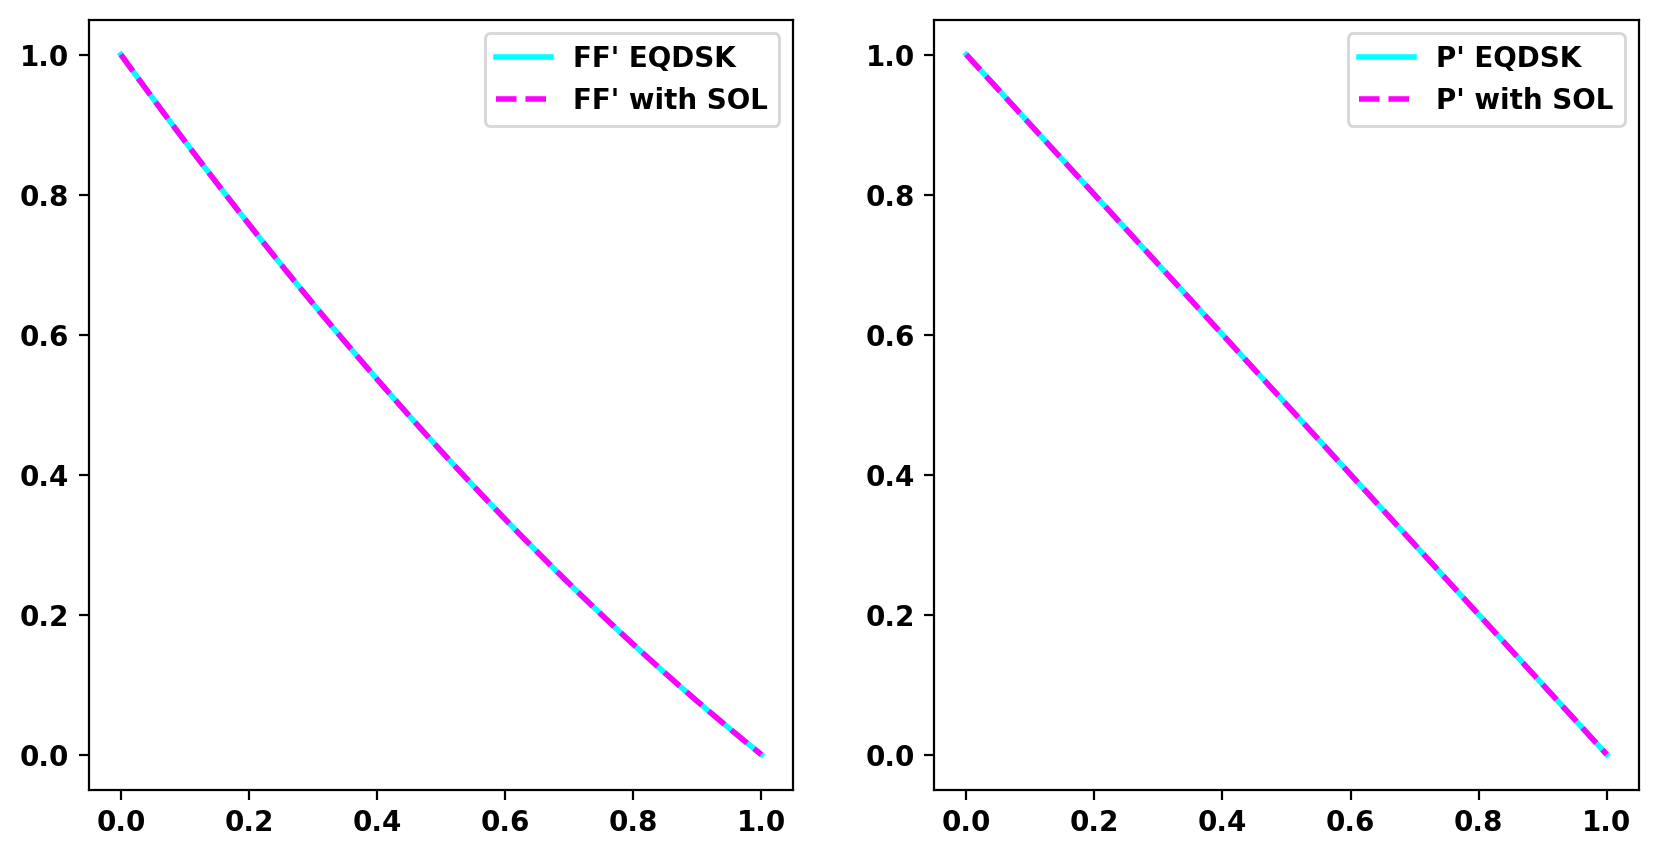

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ffprim = eqdsk['ffprim']
pprime = eqdsk['pprime']

ffprim -= ffprim[-1]
ffprim = ffprim / ffprim[0]

pprime -= pprime[-1]
pprime = pprime / pprime[0]

x = np.linspace(0.0, 1.0, len(ffprim))
x_sol = np.linspace(1.01, 1.3, 25)

ax[0].plot(x, ffprim, label='FF\' EQDSK', color='cyan')
ax[1].plot(x, pprime, label='P\' EQDSK', color='cyan')

# x = np.linspace(0.0, 1.0, len(ffprim))
# x_sol = np.linspace(1.01, 1.3, 25)
# x = np.append(x, x_sol)
# pprime = np.append(pprime, len(x_sol) * [0.0])
# ffprim = np.append(ffprim, len(x_sol) * [0.0]) 

# def supergaussian(psi_n, centr, std=0.05):
#     return np.exp(-(psi_n - centr) ** 4 / (2 * std**4))

# ffp_bump = 0.2 * supergaussian(x, 1.15, std=0.12)
# ffprim += ffp_bump

# pp_bump = 0.2 * supergaussian(x, 1.15, std=0.12)
# pprime += pp_bump

ax[0].plot(x, ffprim, label='FF\' with SOL', linestyle='--', color='magenta')
ax[1].plot(x, pprime, label='P\' with SOL', linestyle='--', color='magenta')

ax[0].legend()
ax[1].legend()
plt.show()

mygs.set_profiles(ffp_prof={'type': 'linterp', 'y': ffprim, 'x': x},pp_prof={'type': 'linterp', 'y': pprime, 'x': x}, f_SOL=False)


## Set LCFS and X Points

In [11]:
lcfs = eqdsk['rzout']
x_pts = np.array([[1.07414162, 1.14583397]])
lcfs = np.vstack((lcfs,x_pts))
mygs.set_isoflux_constraints(lcfs, weights = 1e3 * np.ones_like(lcfs[:,0]))
mygs.set_saddle_constraints(x_pts)

## Compute starting equilibrium

In [12]:
##### Add plasma current and flux loop constraints
Ip_target=abs(eqdsk['ip'])
P0_target=eqdsk['pres'][0]
mygs.set_targets(Ip=Ip_target, pax=P0_target)

target_currents = {}
target_errs = {}

for key in e_coil_dict:
    if e_coil_dict[key][1] == 0:
        continue
    target_currents[key] = e_coil_dict[key][0]
    target_errs[key] = abs(e_coil_dict[key][1])

for key in f_coil_dict:
    if f_coil_dict[key][1] == 0:
        continue
    target_currents[key] = f_coil_dict[key][0] / machine_dict['FCOIL'][key][4]
    target_errs[key] = abs(f_coil_dict[key][1] / machine_dict['FCOIL'][key][4])

# Set coil regularization to weakly track measured coil currents
regularization_terms = []
for key in e_coil_dict:
    if e_coil_dict[key][1] == 0:
        continue
    regularization_terms.append(mygs.coil_reg_term({key: 1.0},
                                                   target=target_currents[key],
                                                   weight=1.0E1))
for key in f_coil_dict:
    if f_coil_dict[key][1] == 0:
            continue
    regularization_terms.append(mygs.coil_reg_term({key: 1.0},
                                                   target=target_currents[key],
                                                   weight=1.0E2))

# Set zero target current and small weight on virtual VSC to allow up-down adjustment
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E-2))

# Pass regularization terms to TokaMaker
mygs.set_coil_reg(reg_terms=regularization_terms)

# Initial equilibrium with very rough guess
R0 = eqdsk['rcentr']
Z0 = 0.0
a = 0.6
kappa = 1.13
delta = .1

err_flag = mygs.init_psi(R0, Z0, a, kappa, delta)

# Compute initial equilibrium
mygs.settings.maxits=1000
mygs.update_settings()
mygs.solve()

Starting non-linear GS solver
     1  4.1109E+00  1.0007E+00  2.0319E-02  1.7187E+00 -1.7645E-02  4.9673E+02
     2  6.0058E+00  8.0434E-01  4.5732E-03  1.7147E+00 -1.8135E-02  4.0712E+02
     3  6.5489E+00  7.6013E-01  1.2386E-03  1.7116E+00 -1.8372E-02  3.8366E+02
     4  6.7360E+00  7.4597E-01  4.3922E-04  1.7098E+00 -1.8497E-02  3.7604E+02
     5  6.8026E+00  7.4114E-01  2.0133E-04  1.7087E+00 -1.8566E-02  3.7338E+02
     6  6.8263E+00  7.3945E-01  1.0372E-04  1.7082E+00 -1.8605E-02  3.7242E+02
     7  6.8345E+00  7.3886E-01  5.5311E-05  1.7079E+00 -1.8628E-02  3.7207E+02
     8  6.8372E+00  7.3866E-01  2.9604E-05  1.7078E+00 -1.8642E-02  3.7197E+02
     9  6.8381E+00  7.3860E-01  1.5712E-05  1.7077E+00 -1.8650E-02  3.7195E+02
    10  6.8382E+00  7.3858E-01  8.2242E-06  1.7076E+00 -1.8655E-02  3.7196E+02
    11  6.8382E+00  7.3858E-01  4.2362E-06  1.7076E+00 -1.8659E-02  3.7198E+02
    12  6.8382E+00  7.3858E-01  2.1467E-06  1.7076E+00 -1.8661E-02  3.7200E+02
    13  6.8382E+00  7.

## Plot starting equilibrium

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.7809E+06
  Current Centroid [m]    =    1.639 -0.013
  Magnetic Axis [m]       =    1.708 -0.019
  Elongation              =    1.885 (U:  1.957, L:  1.814)
  Triangularity           =    0.811 (U:  0.961, L:  0.661)
  Plasma Volume [m^3]     =   19.174
  q_0, q_95               =   -0.765 -3.869
  Plasma Pressure [Pa]    =   Axis:  1.2789E+05, Peak:  1.2789E+05
  Stored Energy [J]       =    8.6757E+05
  <Beta_pol> [%]          =   47.7555
  <Beta_tor> [%]          =    1.6225
  <Beta_n>   [%]          =    1.1587
  Diamagnetic flux [Wb]   =   -4.6174E-02
  Toroidal flux [Wb]      =   -4.6467E+00
  l_i                     =    1.2215


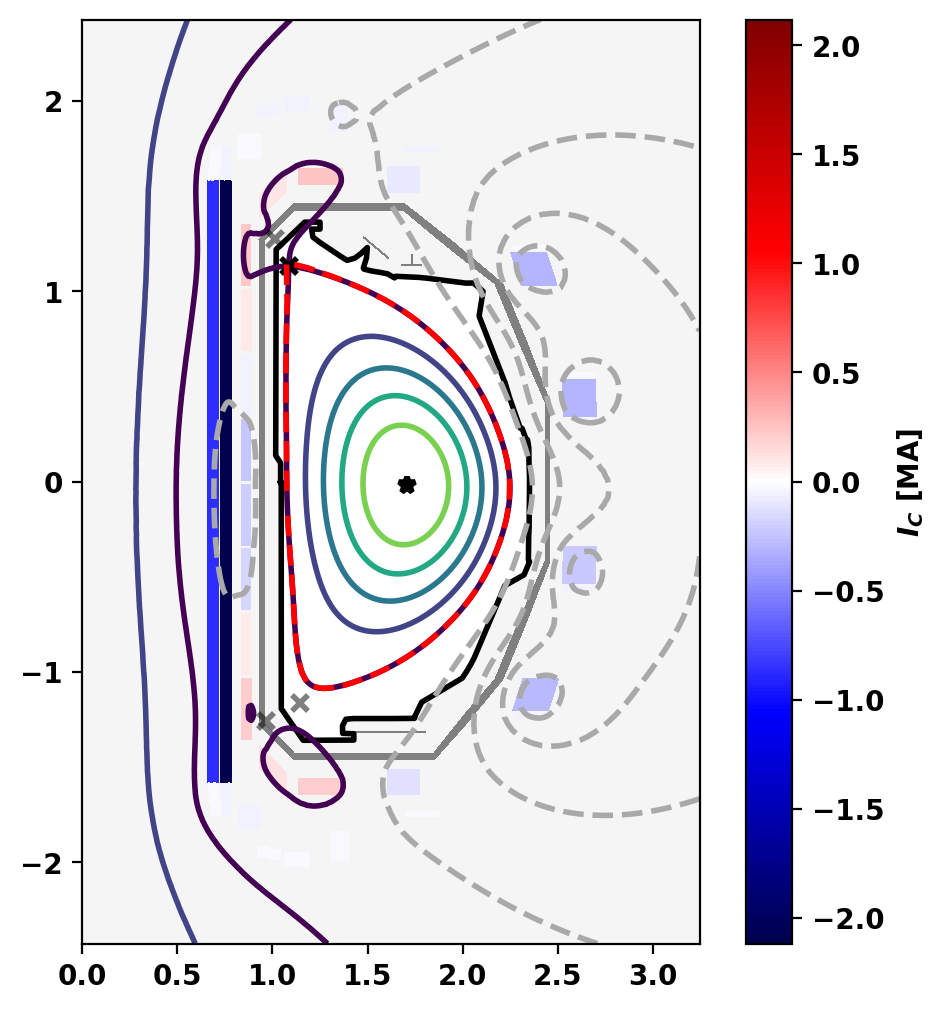

In [13]:
psi_eq = mygs.get_psi()
mygs.print_info()

fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,normalized=True,plasma_nlevels=6,vacuum_nlevels=5)
_ = ax.plot(eqdsk['rzout'][:,0], eqdsk['rzout'][:,1],'r--')

plt.show()

In [14]:
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key, current in coil_currents.items():
    if key not in target_currents:
        continue
    current_adj = current
    # if key.startswith('F'):
    #     current_adj = current/machine_dict['FCOIL'][key][4]
    measured_currt = target_currents[key]
    pct_diff = 100.0 * (current_adj-measured_currt)/measured_currt
    print('  {0:10} {1:11.3F} {2:11.3F} {3:10.2F}%'.format(key+":", current_adj/1.E3, measured_currt/1.E3, pct_diff))

Coil Currents [kA]:
  F1A:            -4.089      -3.510      16.49%
  F2A:            -1.039      -1.508     -31.12%
  F3A:             1.482      -0.047   -3280.57%
  F4A:             3.771       3.113      21.14%
  F5A:             1.828       3.186     -42.63%
  F6A:            -5.567      -4.847      14.86%
  F7A:            -5.598      -5.705      -1.88%
  F8A:             4.118       3.198      28.80%
  F9A:            -1.633      -4.054     -59.71%
  F1B:            -3.428      -2.719      26.09%
  F2B:            -2.998      -3.096      -3.19%
  F3B:             1.608      -0.050   -3335.39%
  F4B:             3.588       2.932      22.38%
  F5B:             2.168       2.679     -19.07%
  F6B:            -4.083      -3.925       4.03%
  F7B:            -5.217      -5.927     -11.98%
  F8B:             3.593       3.905      -7.97%
  F9B:            -2.367      -4.044     -41.46%


## Plot Measured vs. Computed SE Values

### Plot SE Currents

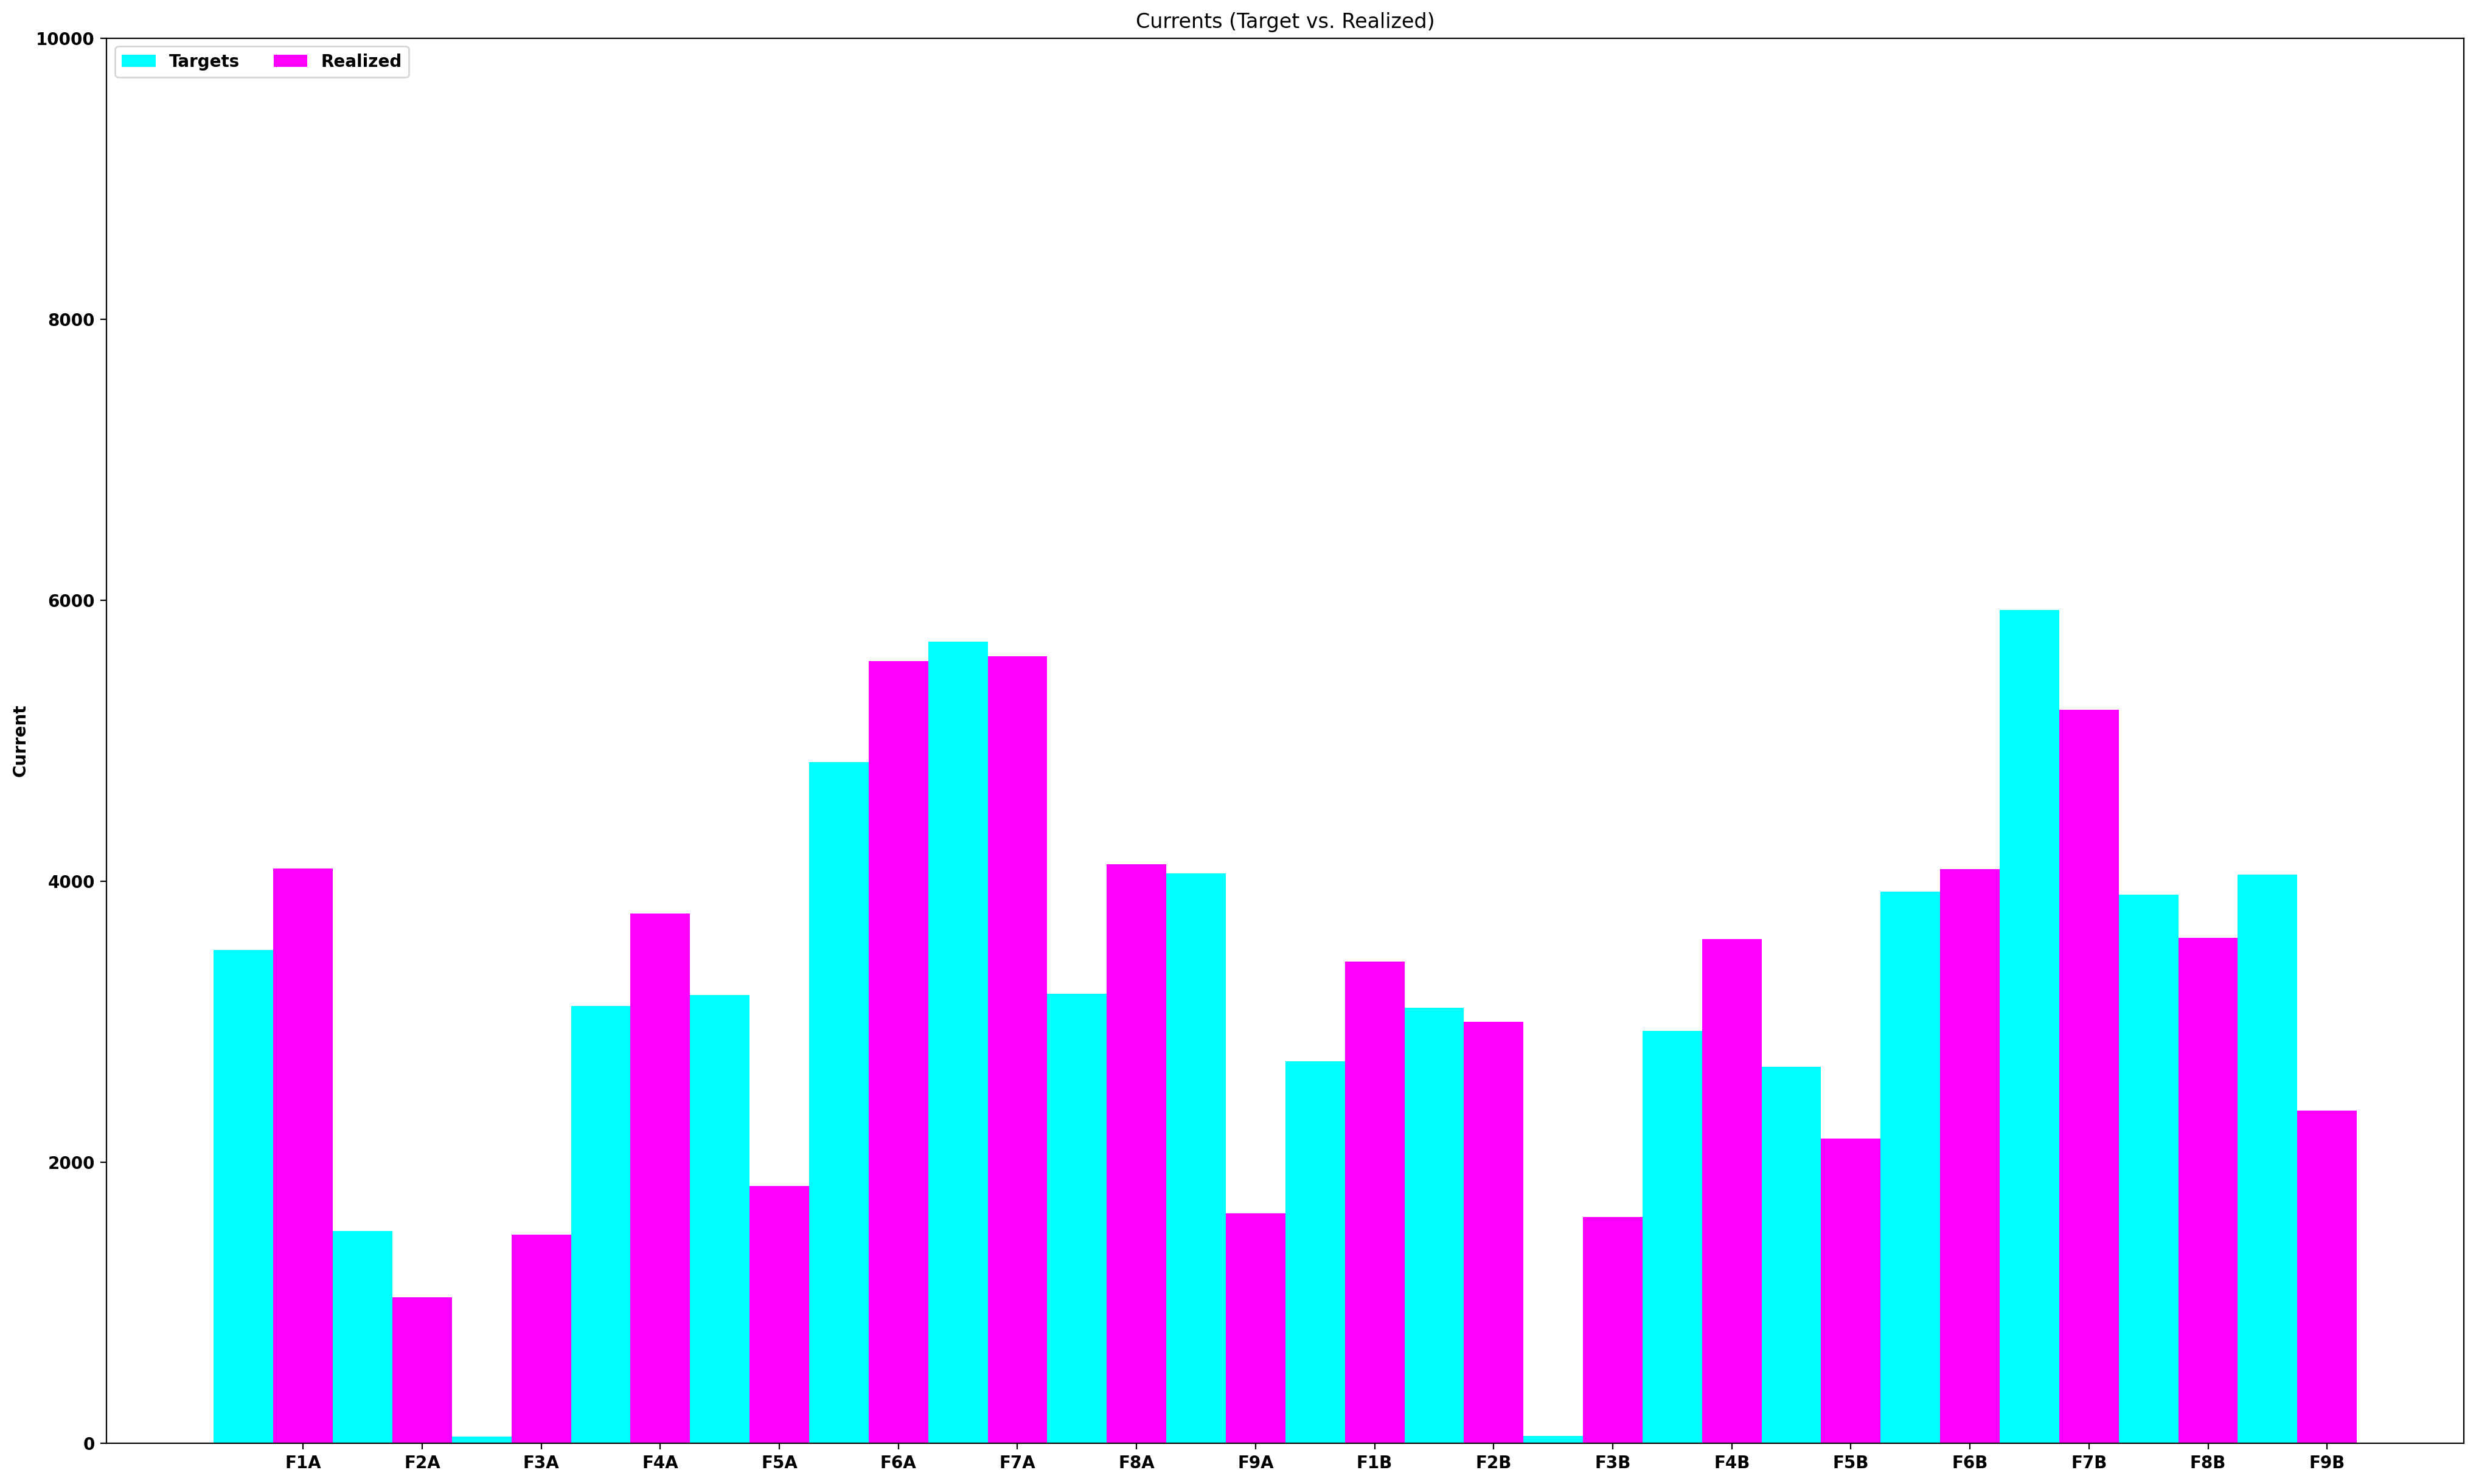

In [15]:
plot_colors = {'Targets': 'cyan', 'Realized': 'magenta', 'Error': 'blue'}

def plot_currents():
    coil_currents, _ = mygs.get_coil_currents()
    coil_names = [key for key in coil_currents if key in target_currents]
    coil_info = {'Targets': [abs(target_currents[key]) for key in coil_names if key in target_currents],
                 'Realized': [abs(coil_currents[key]) for key in coil_names if key in target_currents]}
    coil_err = np.array([np.abs(target_errs[key]) for key in coil_names if key in target_currents])

    x = np.arange(len(coil_names))  # the label locations
    width = 0.5  # the width of the bars
    multiplier = 0
    
    fig, ax = plt.subplots(figsize=(25, 15))
    
    for attribute, measurement in coil_info.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute, color=plot_colors[attribute])
        multiplier += 1
    
    ax.set_ylabel('Current')
    ax.set_title('Currents (Target vs. Realized)')
    ax.set_xticks(x + width, coil_names)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.0E4)

    x_c = np.arange(len(coil_names))

    plt.show()

plot_currents()

### Perform Reconstruction

In [16]:
myrecon = reconstruction(mygs)

def convert_Mirnov_coordinates(sensor):
    R, z, angle = sensor
    position = np.array([R, z])

    angle_rads = angle * np.pi / 180
    orientation = np.array([np.cos(angle_rads), 0, np.sin(angle_rads)])
    return position, orientation

B_vals = [probes_dict[key][0] for key in mag_sensors if key in probes_dict]
B_mean = np.mean(np.positive(B_vals))
mirnov_names = []

for key, mag in mag_sensors.items():
    if probes_dict[key][1] == 0:
        print("{} not selected.".format(key))
        continue
    position, orientation = convert_Mirnov_coordinates(mag)
    mirnov_names.append(key)
    B_meas, _ = probes_dict[key]
    myrecon.add_Mirnov(position, orientation, B_meas, err=0.1*max(B_mean, abs(B_meas)))

flux_locs = []
flux_vals = []

psi_vals = [loops_dict[key][0] for key in flux_loops if key in loops_dict]
psi_mean = np.mean(np.positive(psi_vals))

flux_names = []

for key, fl in flux_loops.items():
    if loops_dict[key][1] == 0:
        print("{} not selected.".format(key))
        continue
    flux_names.append(key)
    B_tmp, _ = loops_dict[key]
    flux_locs.append(fl)
    flux_vals.append(B_tmp)
    psi_val = B_tmp*2.0*np.pi
    myrecon.add_flux_loop(fl, psi_val, err=0.1*(max(psi_mean, abs(psi_val))))

# mygs.set_flux(np.array(flux_locs), np.array(flux_vals), weights=100*np.ones_like(flux_vals))

# Remove all shape constraints
mygs.set_isoflux(None)
mygs.set_flux(None,None)
mygs.set_saddles(None)

# Set initial position targets from current values
mygs.set_targets(R0=mygs.o_point[0],V0=mygs.o_point[1])

# Set Recon Plasma Current
myrecon.set_Ip(Ip_target, err=0.1*Ip_target)

# Set reconstruction settings
# myrecon.settings.fit_Pscale = False
# myrecon.settings.fitR0 = True
# myrecon.settings.fitZ0 = True
# myrecon.settings.fitCoils = True
# myrecon.settings.pm = False

myrecon.settings.fitF = True
myrecon.settings.fitP = True
myrecon.settings.fit_Pscale = True
myrecon.settings.fit_FFPscale = False
myrecon.settings.fitR0 = False
myrecon.settings.fitZ0 = False
myrecon.settings.fixedCentering = False

# Perform reconstructions
mygs.settings.nl_tol=1.E-6
err_flag = myrecon.reconstruct()

MPI66M247 not selected.
MPI79A147 not selected.
MPI6NA132 not selected.
MPI7NB322 not selected.
DSL3U180 not selected.
MPI5U157 not selected.
MPI6U157 not selected.
MPI7U157 not selected.
DSL5U157 not selected.
DSL6U157 not selected.
MPI3L180 not selected.
PSF3A not selected.
PSF7NA not selected.
PSI34A not selected.
PSF6FB not selected.
PSI89FB not selected.
PSI2L not selected.

*** Loading fit constraints ***

Starting Fit:
  # of free parameters   =  511
  # of constraints       =  104

Function evaluation    1
  FFp_scale         =  6.838E+00
  P_scale           =  7.386E-01
  Z0_target         = -1.866E-02
  F_cofs            =  5.753E-03  8.641E-03  1.154E-02  1.444E-02  1.736E-02  2.028E-02  2.320E-02  2.614E-02  2.909E-02  3.204E-02  3.500E-02  3.797E-02  4.095E-02  4.394E-02  4.693E-02  4.993E-02  5.294E-02  5.596E-02  5.899E-02  6.202E-02  6.506E-02  6.811E-02  7.117E-02  7.424E-02  7.731E-02  8.040E-02  8.349E-02  8.659E-02  8.969E-02  9.281E-02  9.593E-02  9.907E-02  1.022E

/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_99962/2806172274.py:46: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_99962/2806172274.py:47: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(None,None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_99962/2806172274.py:48: DeprecationWarning: `set_saddles()` is deprecated, use `set_saddle_constraints()` instead. This function will be removed in a future version.
  mygs.set_saddles(None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_99962/2806172274.py:51: DeprecationWarning: `V0` is deprecated, use `Z0` instead. This argument will be removed in a future version.
  mygs.set_targets(R0=mygs.o_point[0],V0=mygs.o_point[1])


  FFp_scale         =  6.838E+00
  P_scale           =  7.386E-01
  Z0_target         = -1.866E-02
  F_cofs            =  5.753E-03  8.641E-03  1.154E-02  1.444E-02  1.736E-02  2.028E-02  2.320E-02  2.614E-02  2.909E-02  3.204E-02  3.500E-02  3.797E-02  4.095E-02  4.394E-02  4.693E-02  4.993E-02  5.294E-02  5.596E-02  5.899E-02  6.202E-02  6.506E-02  6.811E-02  7.117E-02  7.424E-02  7.731E-02  8.040E-02  8.349E-02  8.659E-02  8.969E-02  9.281E-02  9.593E-02  9.907E-02  1.022E-01  1.054E-01  1.085E-01  1.117E-01  1.148E-01  1.180E-01  1.212E-01  1.244E-01  1.276E-01  1.308E-01  1.341E-01  1.373E-01  1.405E-01  1.438E-01  1.470E-01  1.503E-01  1.535E-01  1.568E-01  1.601E-01  1.634E-01  1.667E-01  1.700E-01  1.733E-01  1.767E-01  1.800E-01  1.833E-01  1.867E-01  1.900E-01  1.934E-01  1.968E-01  2.002E-01  2.036E-01  2.070E-01  2.104E-01  2.138E-01  2.172E-01  2.206E-01  2.241E-01  2.275E-01  2.310E-01  2.345E-01  2.379E-01  2.414E-01  2.449E-01  2.484E-01  2.519E-01  2.554E-01  2.589E-01

### Print equilibrium information and coil currents
As above we use \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.print_info "print_info()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_coil_currents "get_coil_currents()" to display information on the final equilibrium.

In [17]:
mygs.print_info()

print()
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key, current in coil_currents.items():
    if key not in target_currents:
        continue
    measured_currt = target_currents[key]
    pct_diff = 100.0 * (current-measured_currt)/measured_currt
    print('  {0:10} {1:11.3F} {2:11.3F} {3:10.2F}%'.format(key+":", current/1.E3, measured_currt/1.E3, pct_diff))

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.7809E+06
  Current Centroid [m]    =    1.639 -0.013
  Magnetic Axis [m]       =    1.708 -0.019
  Elongation              =    1.885 (U:  1.957, L:  1.814)
  Triangularity           =    0.811 (U:  0.962, L:  0.660)
  Plasma Volume [m^3]     =   19.173
  q_0, q_95               =   -0.765 -3.869
  Plasma Pressure [Pa]    =   Axis:  1.2789E+05, Peak:  1.2789E+05
  Stored Energy [J]       =    8.6755E+05
  <Beta_pol> [%]          =   48.1581
  <Beta_tor> [%]          =    1.6225
  <Beta_n>   [%]          =    1.1587
  Diamagnetic flux [Wb]   =   -4.6173E-02
  Toroidal flux [Wb]      =   -4.6466E+00
  l_i                     =    1.2318

Coil Currents [kA]:
  F1A:            -4.089      -3.510      16.49%
  F2A:            -1.039      -1.508     -31.12%
  F3A:             1.482      -0.047   -3280.57%
  F4A:             3.771       3.113      21.14%
  F5A:             1.828       3.186     -42

## Plot final reconstructed equilibrium

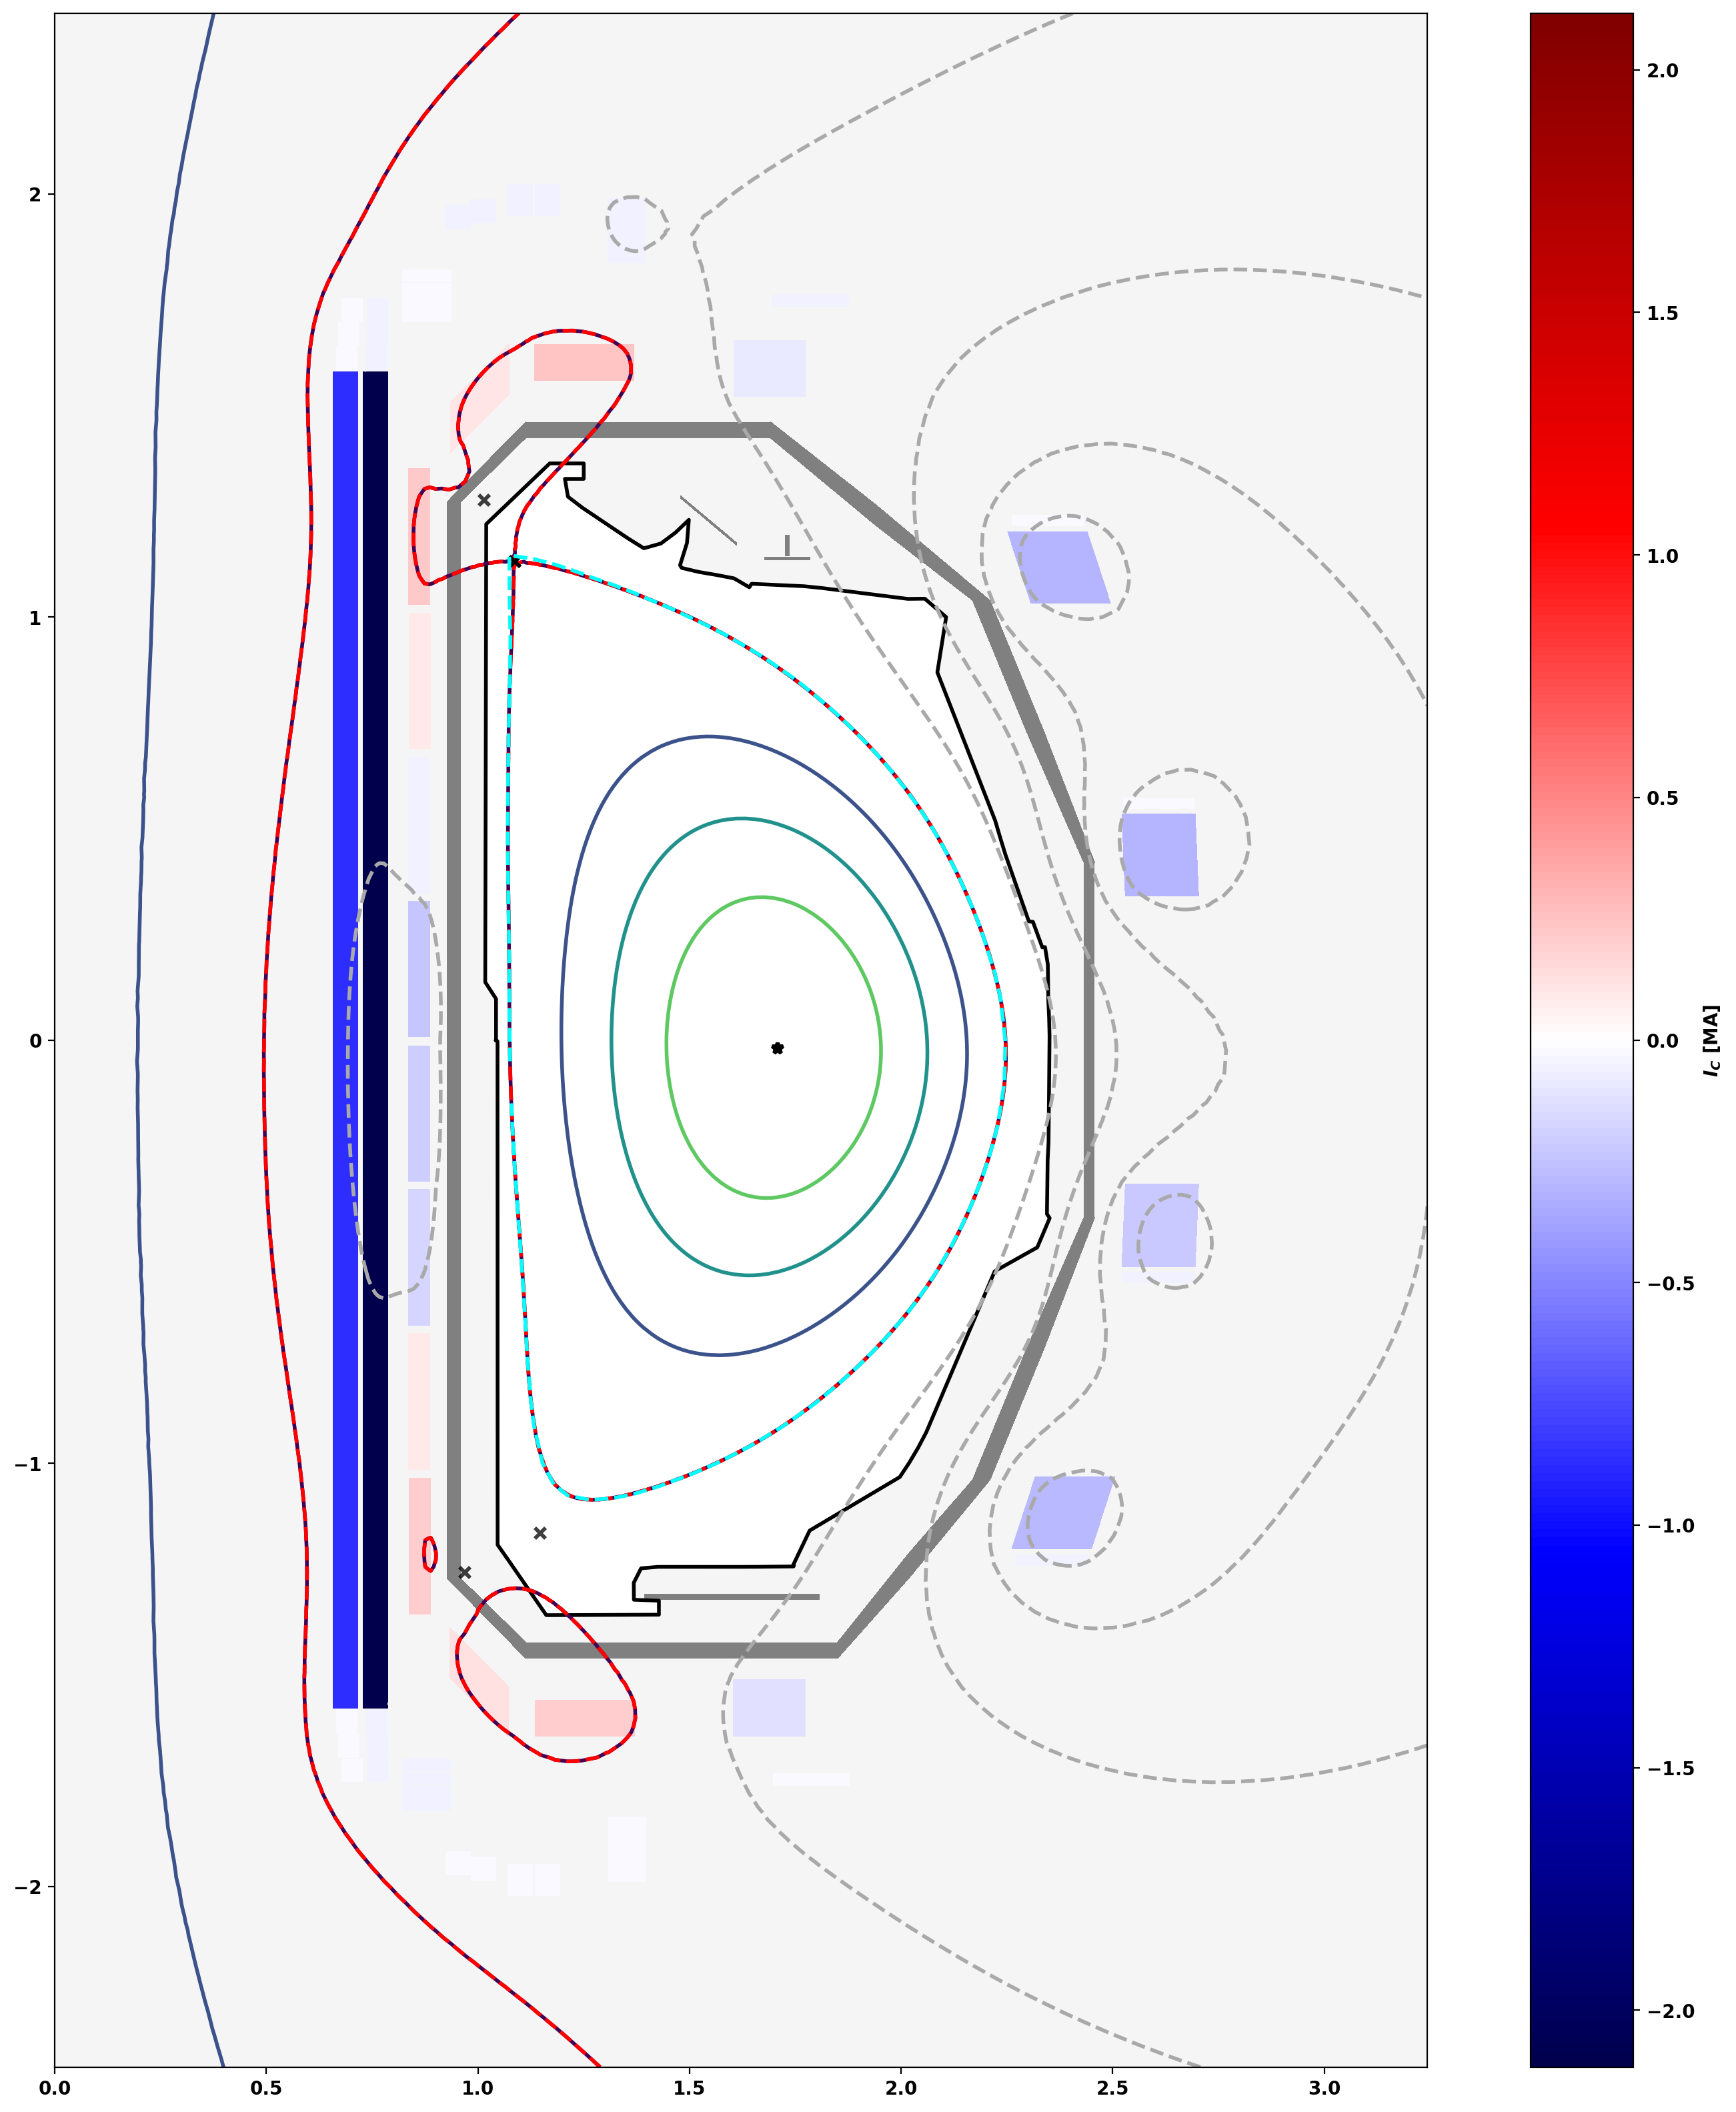

In [18]:
fig, ax = plt.subplots(1,1, figsize=(20,20))

# Plot Psi
psi_recons = mygs.get_psi()
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_psi(fig,ax,psi=psi_recons,plasma_levels=[1.0,],plasma_color='red',vacuum_nlevels=0,plasma_linestyles='dashed')

LCFS_eqdsk = eqdsk['rzout']
ax.plot(LCFS_eqdsk[:,0], LCFS_eqdsk[:,1], color='cyan', linestyle='--')

plt.show()

## Plot Current Density

Starting CG solver
     0  0.000000E+00  0.000000E+00  9.752013E-01
     1 -9.914177E+02  3.581866E+03  4.728378E-01  1.320088E-04
     2 -1.214874E+03  3.429600E+03  2.005103E-01  5.846464E-05
     3 -1.239908E+03  3.586519E+03  7.072408E-02  1.971942E-05
     4 -1.243255E+03  3.598612E+03  2.836451E-02  7.882069E-06
     5 -1.243826E+03  3.601452E+03  1.027475E-02  2.852948E-06
     6 -1.243890E+03  3.592956E+03  3.396246E-03  9.452511E-07
     7 -1.243898E+03  3.591570E+03  1.285534E-03  3.579309E-07
     8 -1.243899E+03  3.591068E+03  5.231386E-04  1.456777E-07
     9 -1.243899E+03  3.590917E+03  2.077129E-04  5.784397E-08
    10 -1.243899E+03  3.590998E+03  8.533533E-05  2.376368E-08
    20 -1.243899E+03  3.591062E+03  5.980662E-09  1.665430E-12


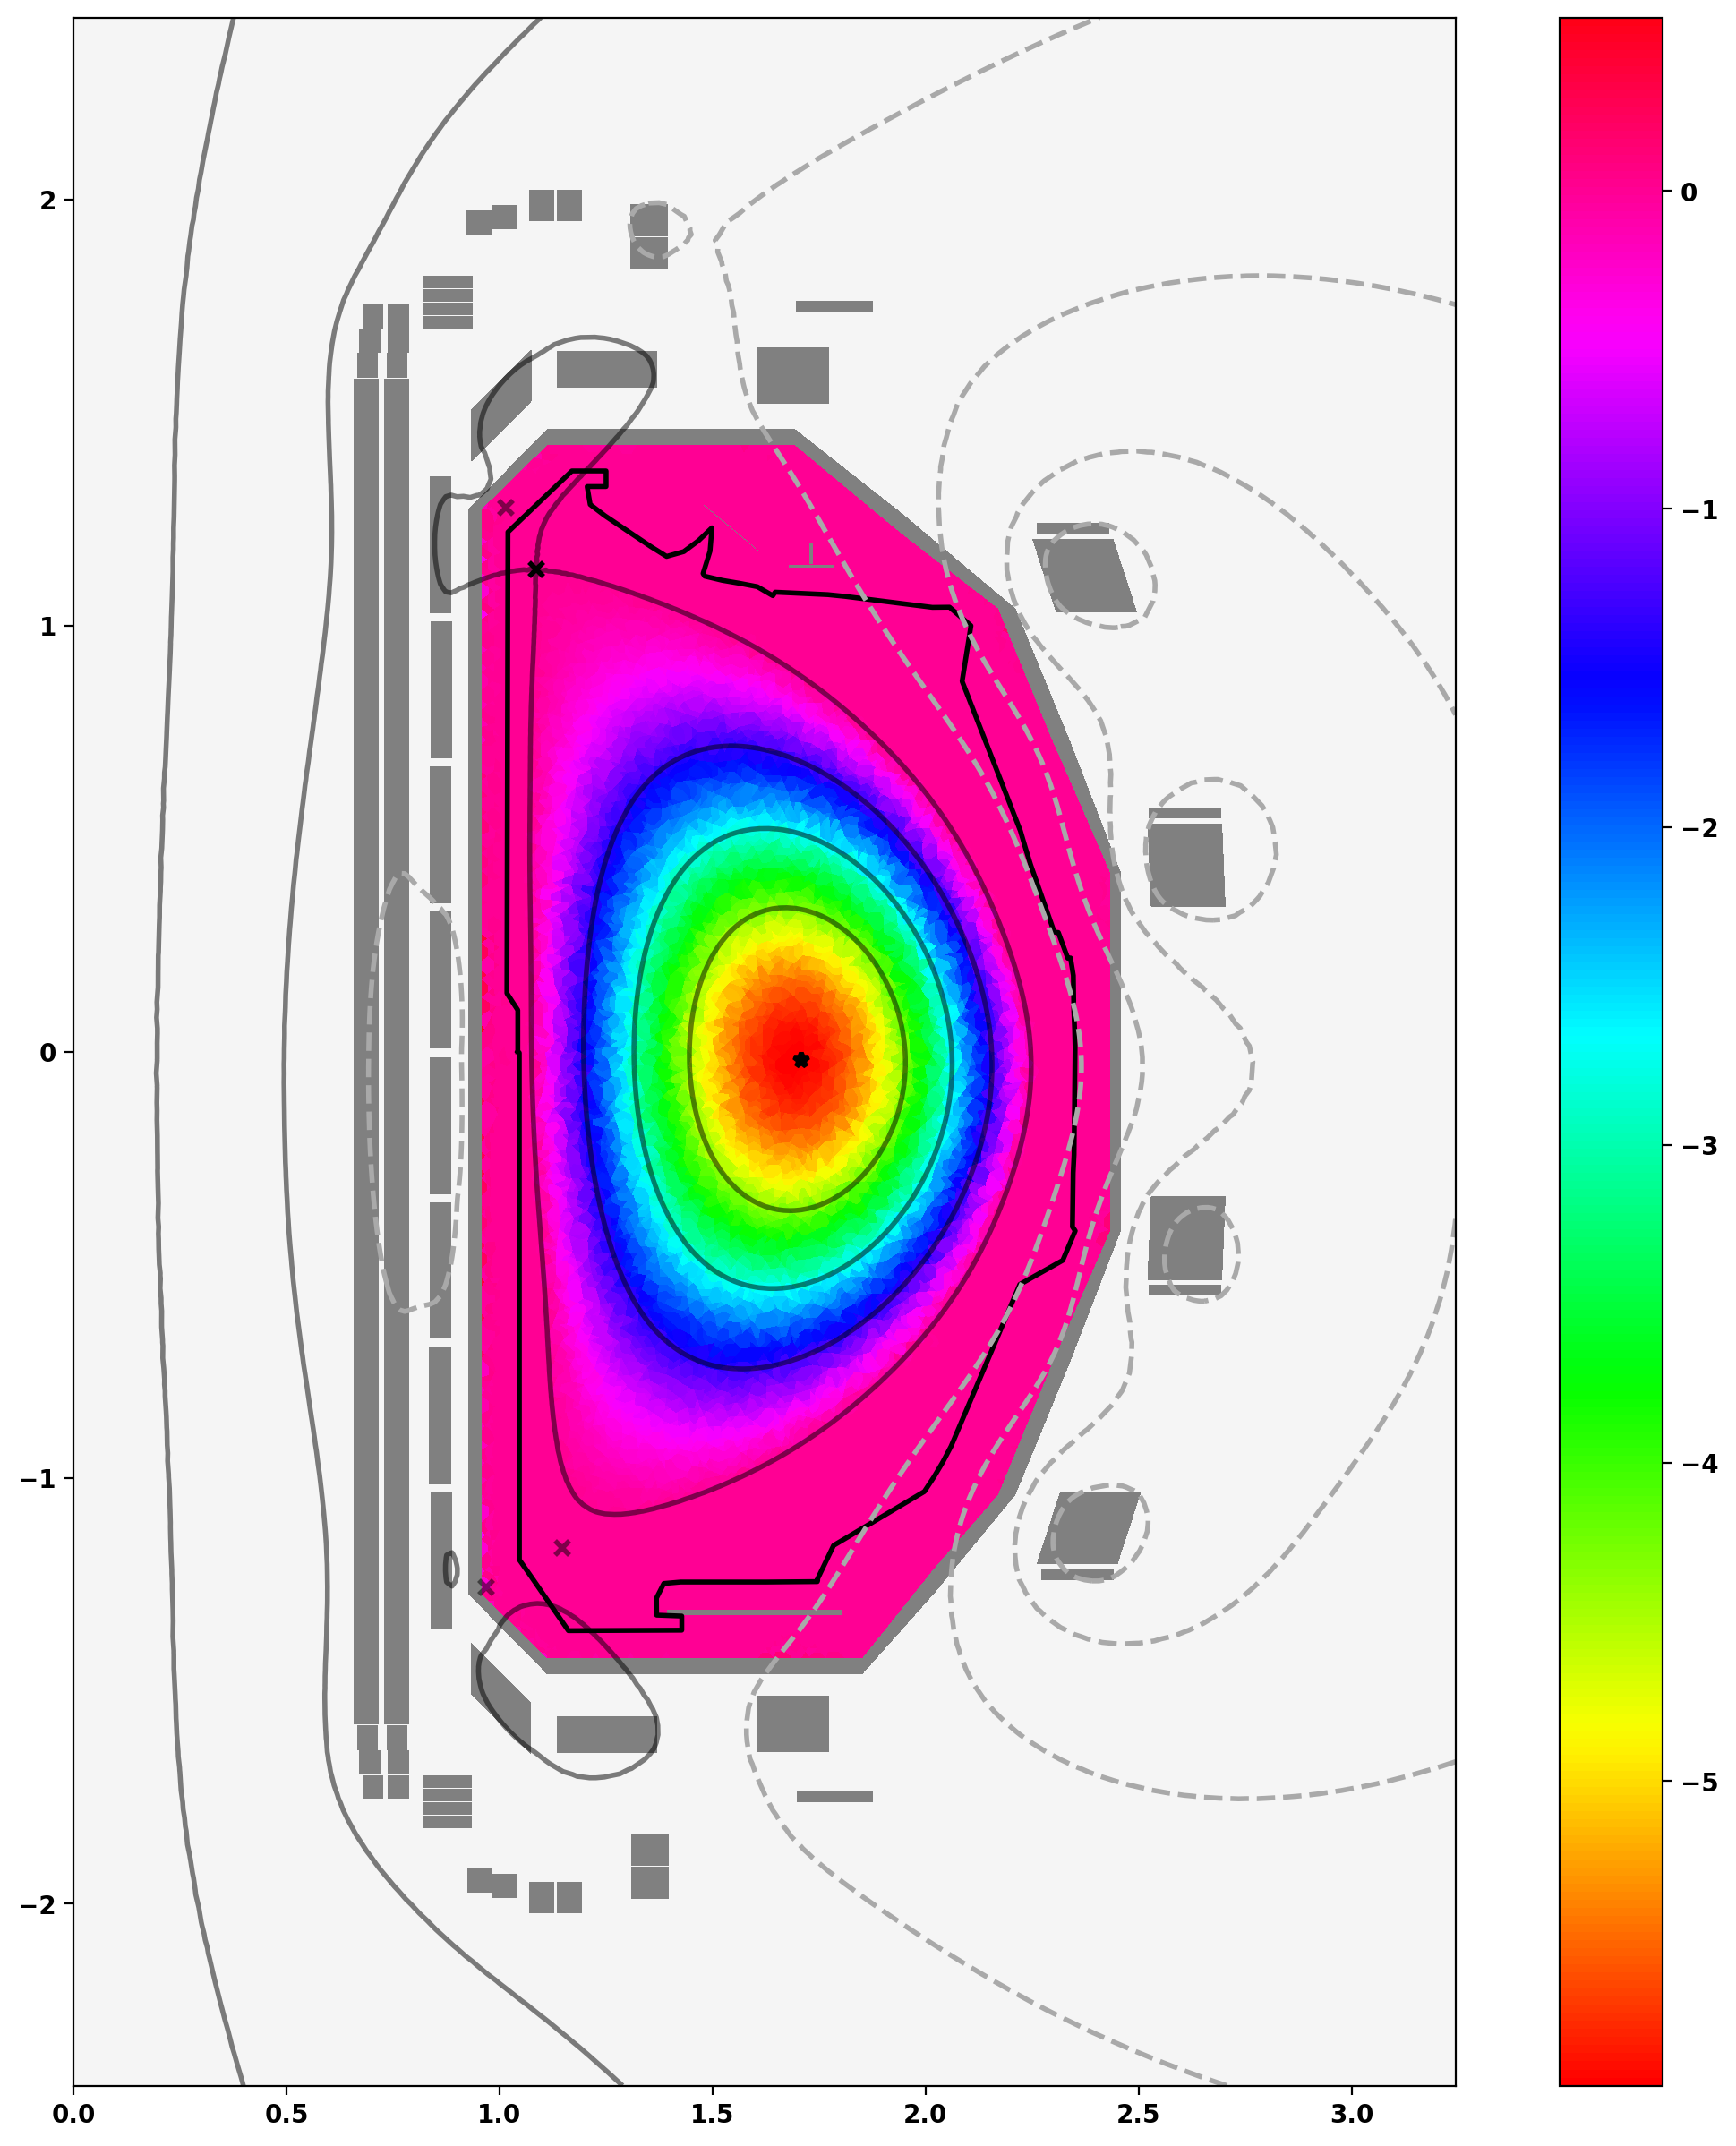

In [19]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(1,1, figsize=(15,15))
cmap = ListedColormap([[0.0, 0.0, 0.0, 0.5]])

mygs.plot_machine(fig,ax,coil_clabel=None)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5, plasma_colormap=cmap)
mygs.plot_current_density(fig, ax, cmap='hsv')

# Show the plot
plt.show()

## Plot Current Density in Divertor Region

Starting CG solver
     0  0.000000E+00  0.000000E+00  9.752013E-01
     1 -9.914177E+02  3.581866E+03  4.728378E-01  1.320088E-04
     2 -1.214874E+03  3.429600E+03  2.005103E-01  5.846464E-05
     3 -1.239908E+03  3.586519E+03  7.072408E-02  1.971942E-05
     4 -1.243255E+03  3.598612E+03  2.836451E-02  7.882069E-06
     5 -1.243826E+03  3.601452E+03  1.027475E-02  2.852948E-06
     6 -1.243890E+03  3.592956E+03  3.396246E-03  9.452511E-07
     7 -1.243898E+03  3.591570E+03  1.285534E-03  3.579309E-07
     8 -1.243899E+03  3.591068E+03  5.231386E-04  1.456777E-07
     9 -1.243899E+03  3.590917E+03  2.077129E-04  5.784397E-08
    10 -1.243899E+03  3.590998E+03  8.533533E-05  2.376368E-08
    20 -1.243899E+03  3.591062E+03  5.980662E-09  1.665430E-12


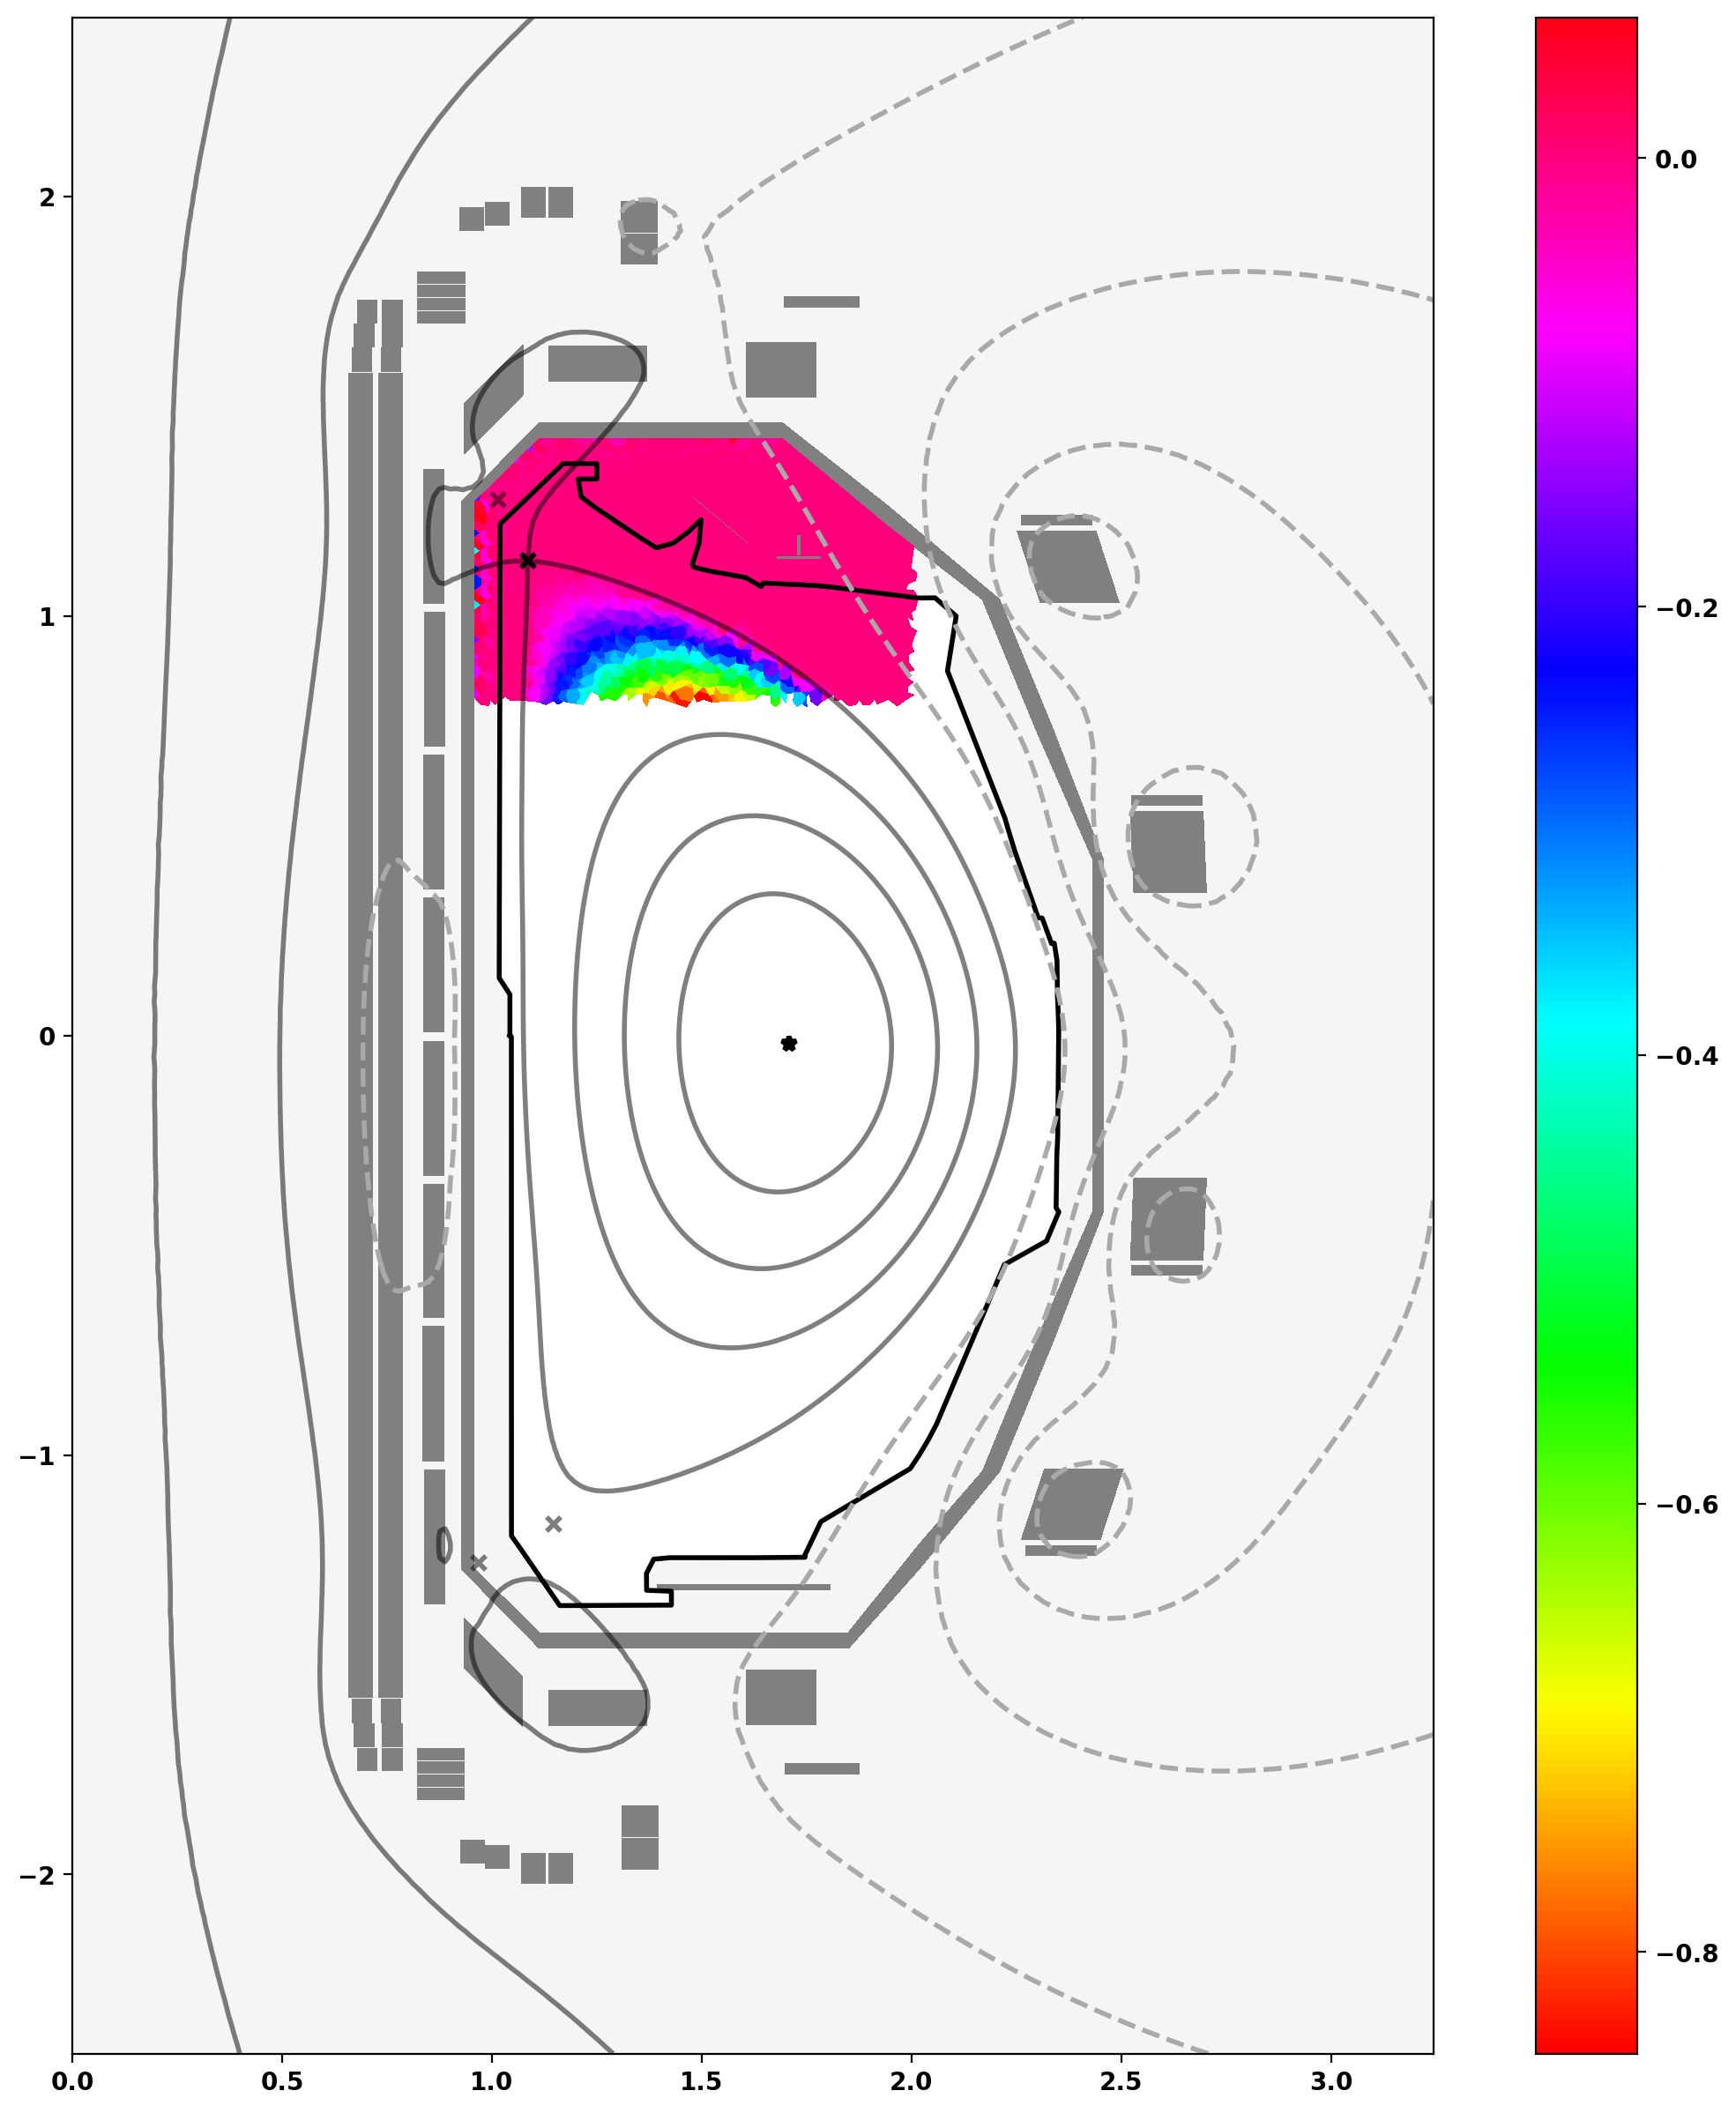

In [23]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(1,1, figsize=(15,15))
cmap = ListedColormap([[0.0, 0.0, 0.0, 0.5]])

mygs.plot_machine(fig,ax,coil_clabel=None)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5, plasma_colormap=cmap)
mygs.plot_current_density(fig, ax, window=[0.8, 2.0, .8, 2.8], cmap='hsv')

# Show the plot
plt.show()

## Plot Currents

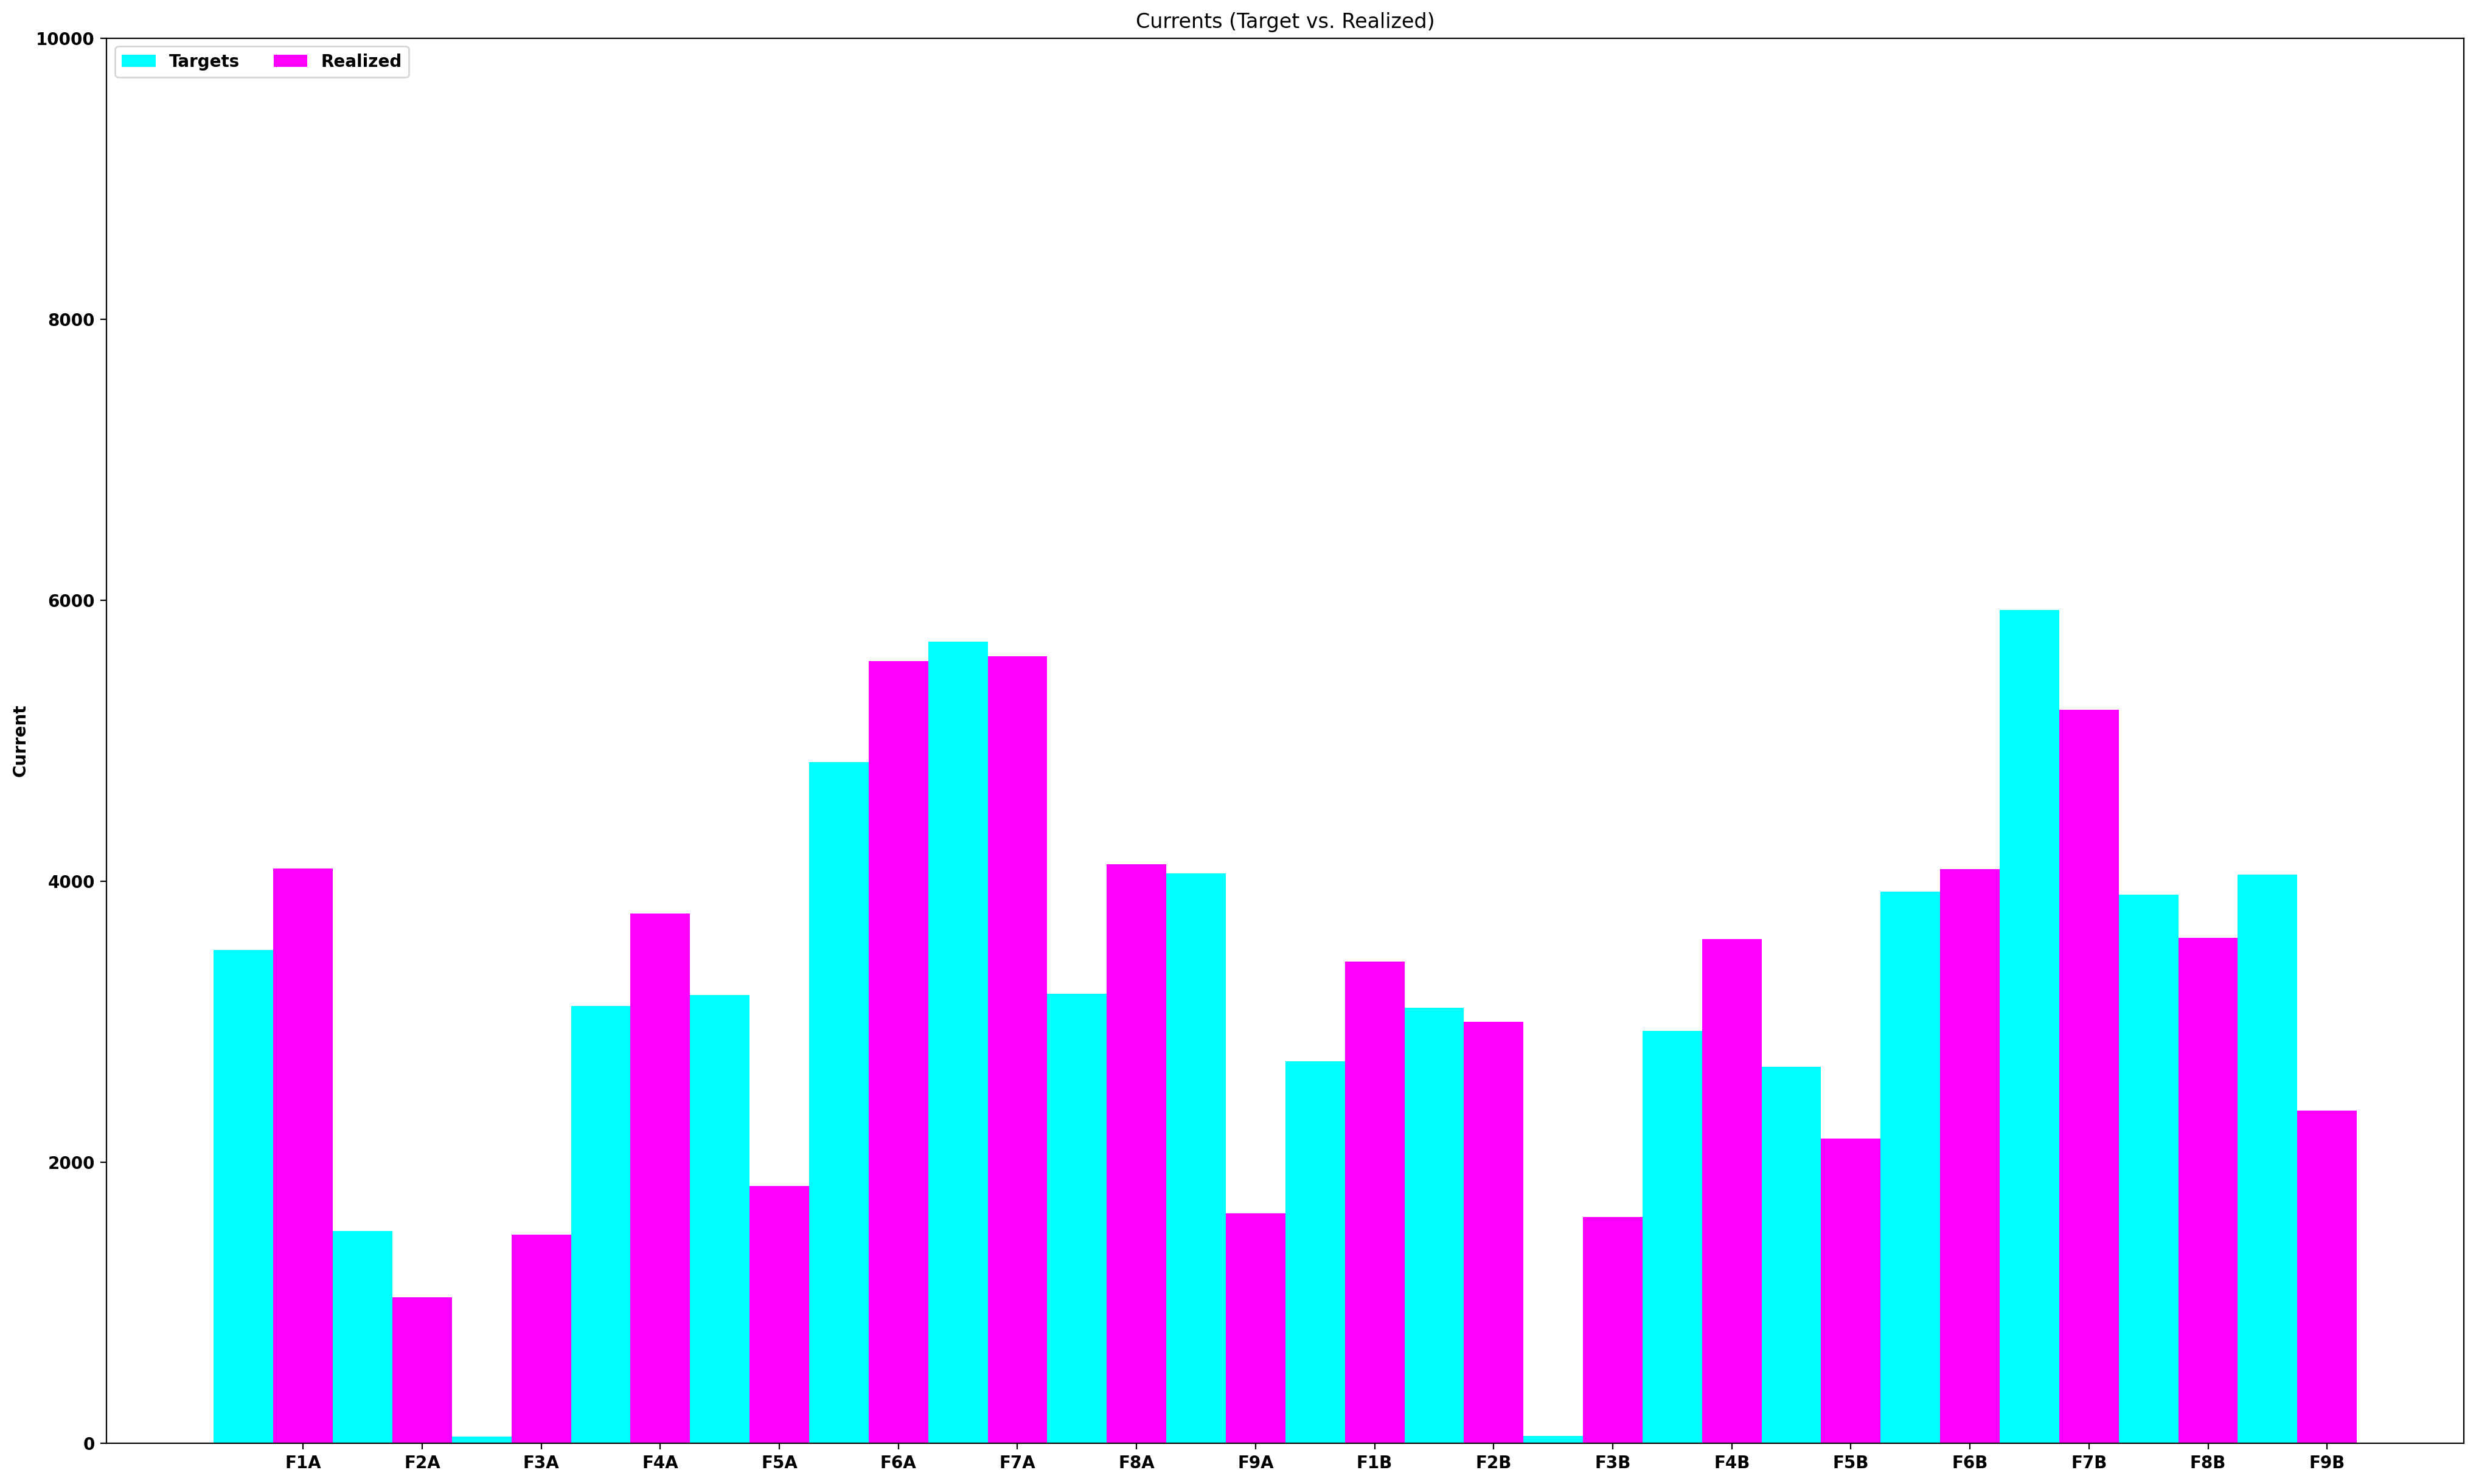

In [21]:
plot_currents()

In [22]:
plot_mirnov()

NameError: name 'plot_mirnov' is not defined

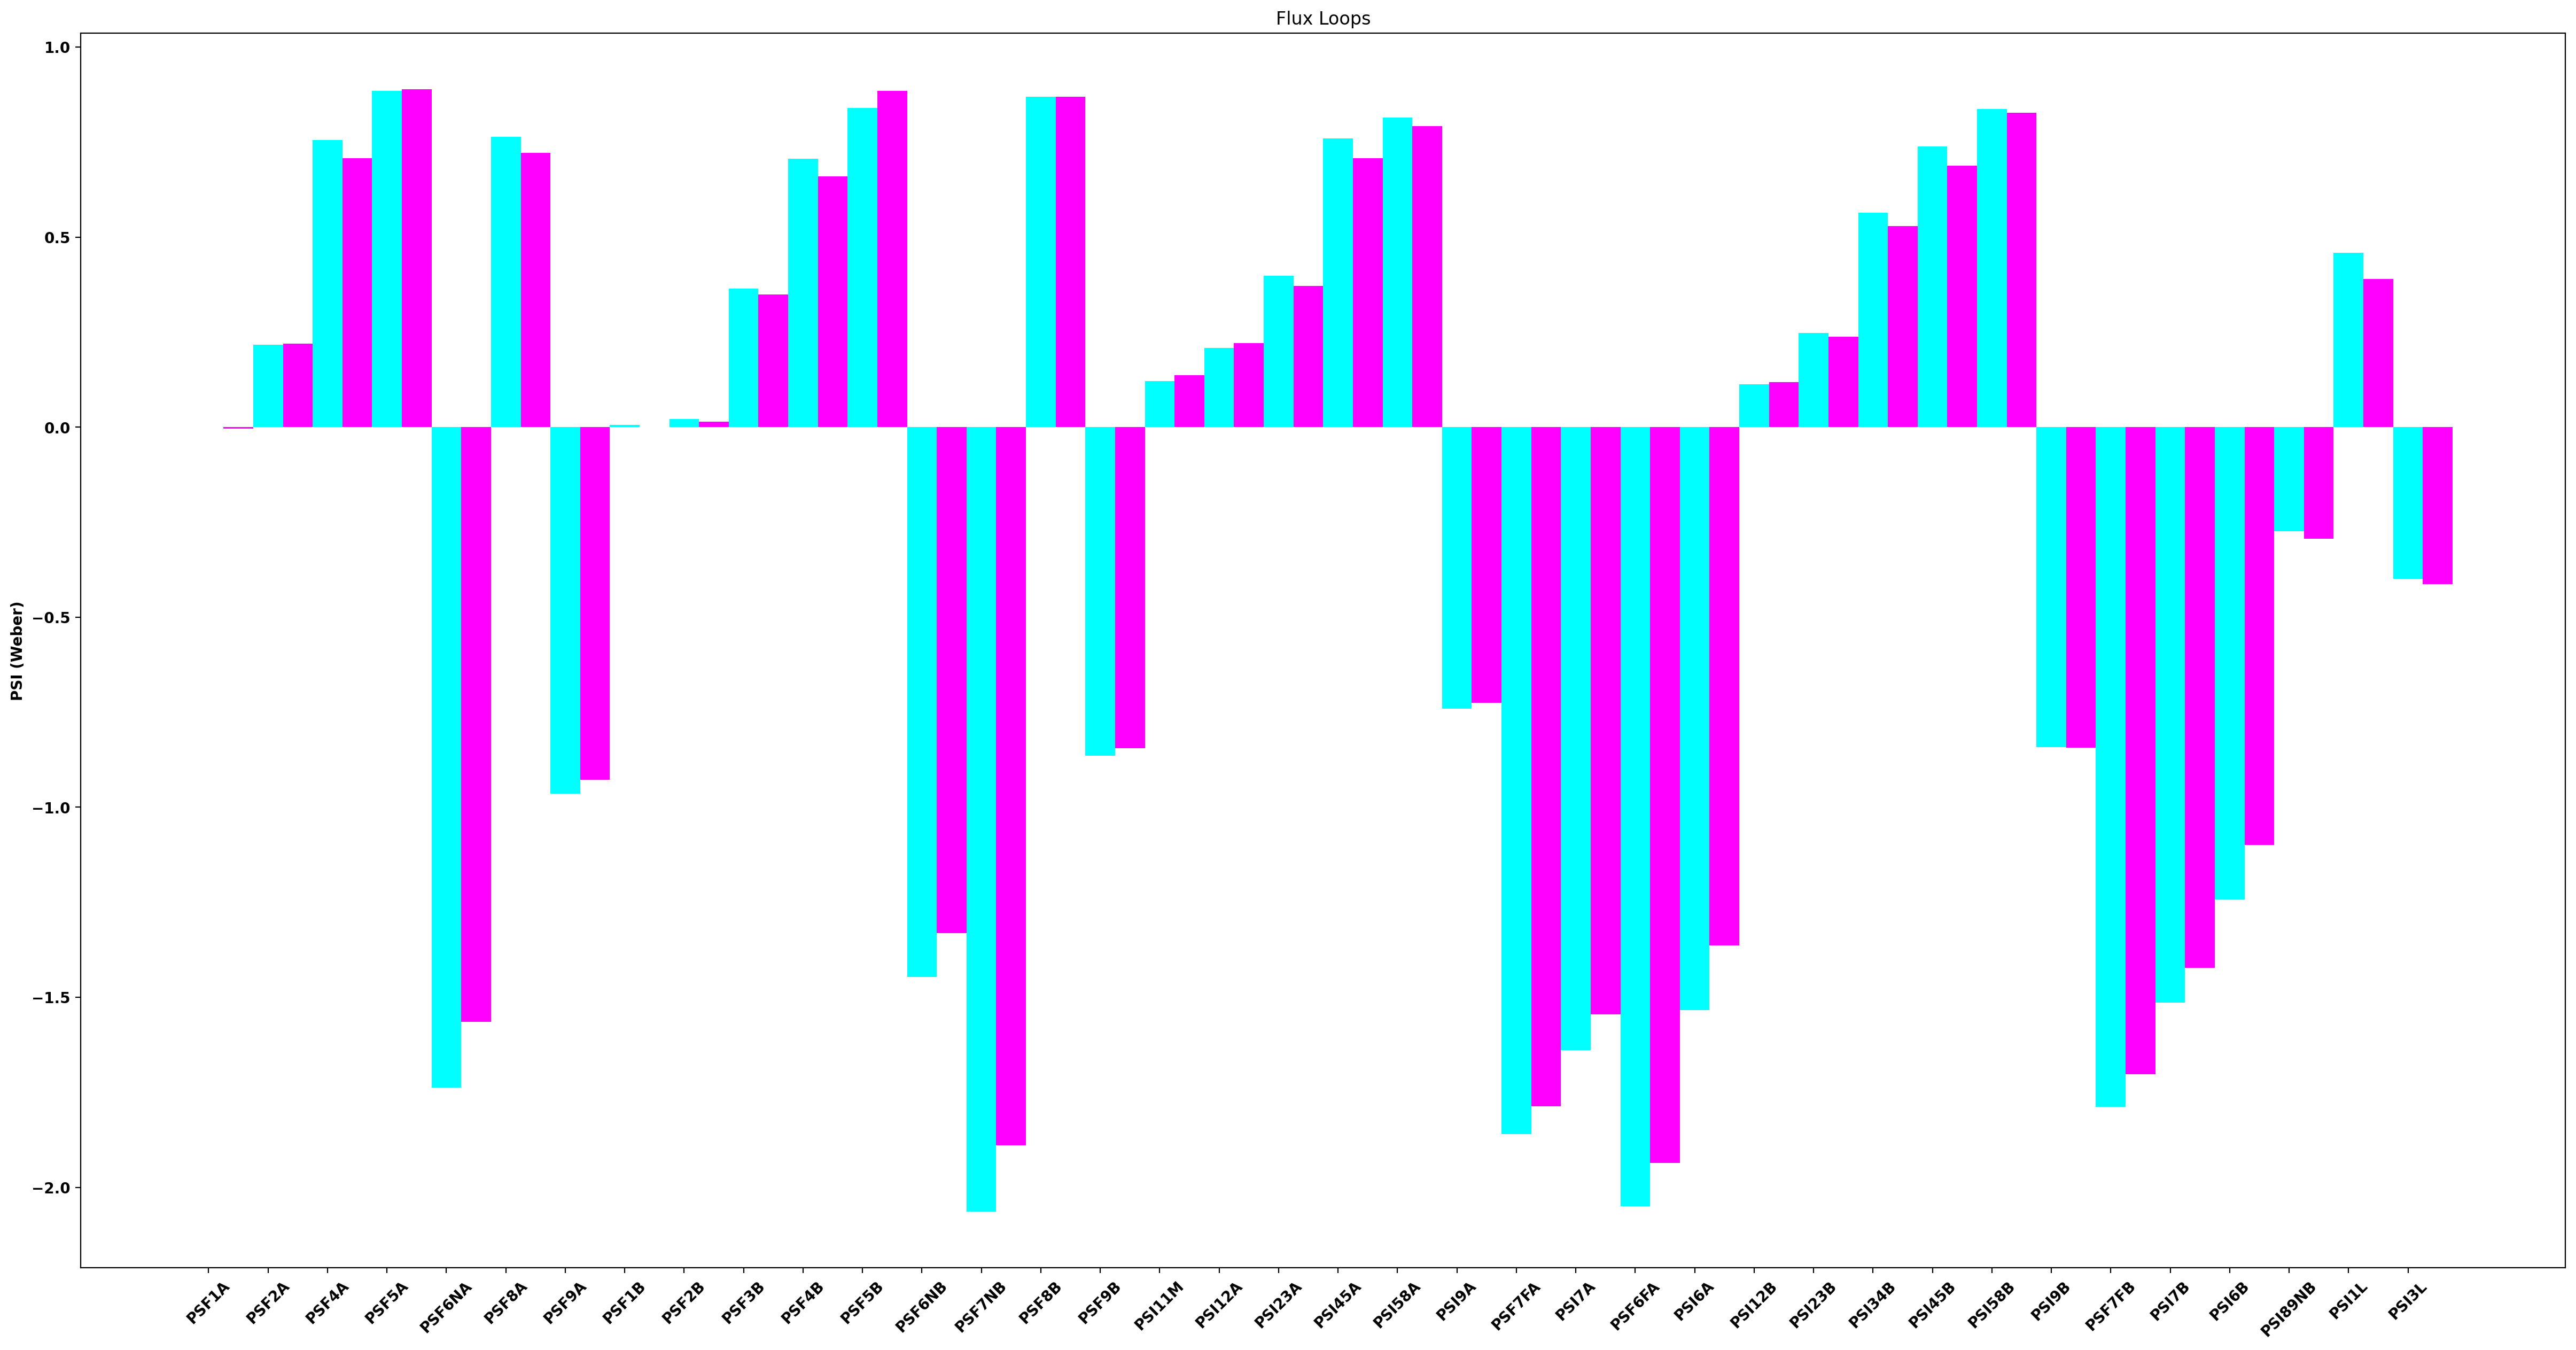

In [ ]:
plot_flux()

## Get Strike Points

In [ ]:
strike_pts = mygs.get_strike_points()

[np.float64(1.04631996), np.float64(1.04631996)]


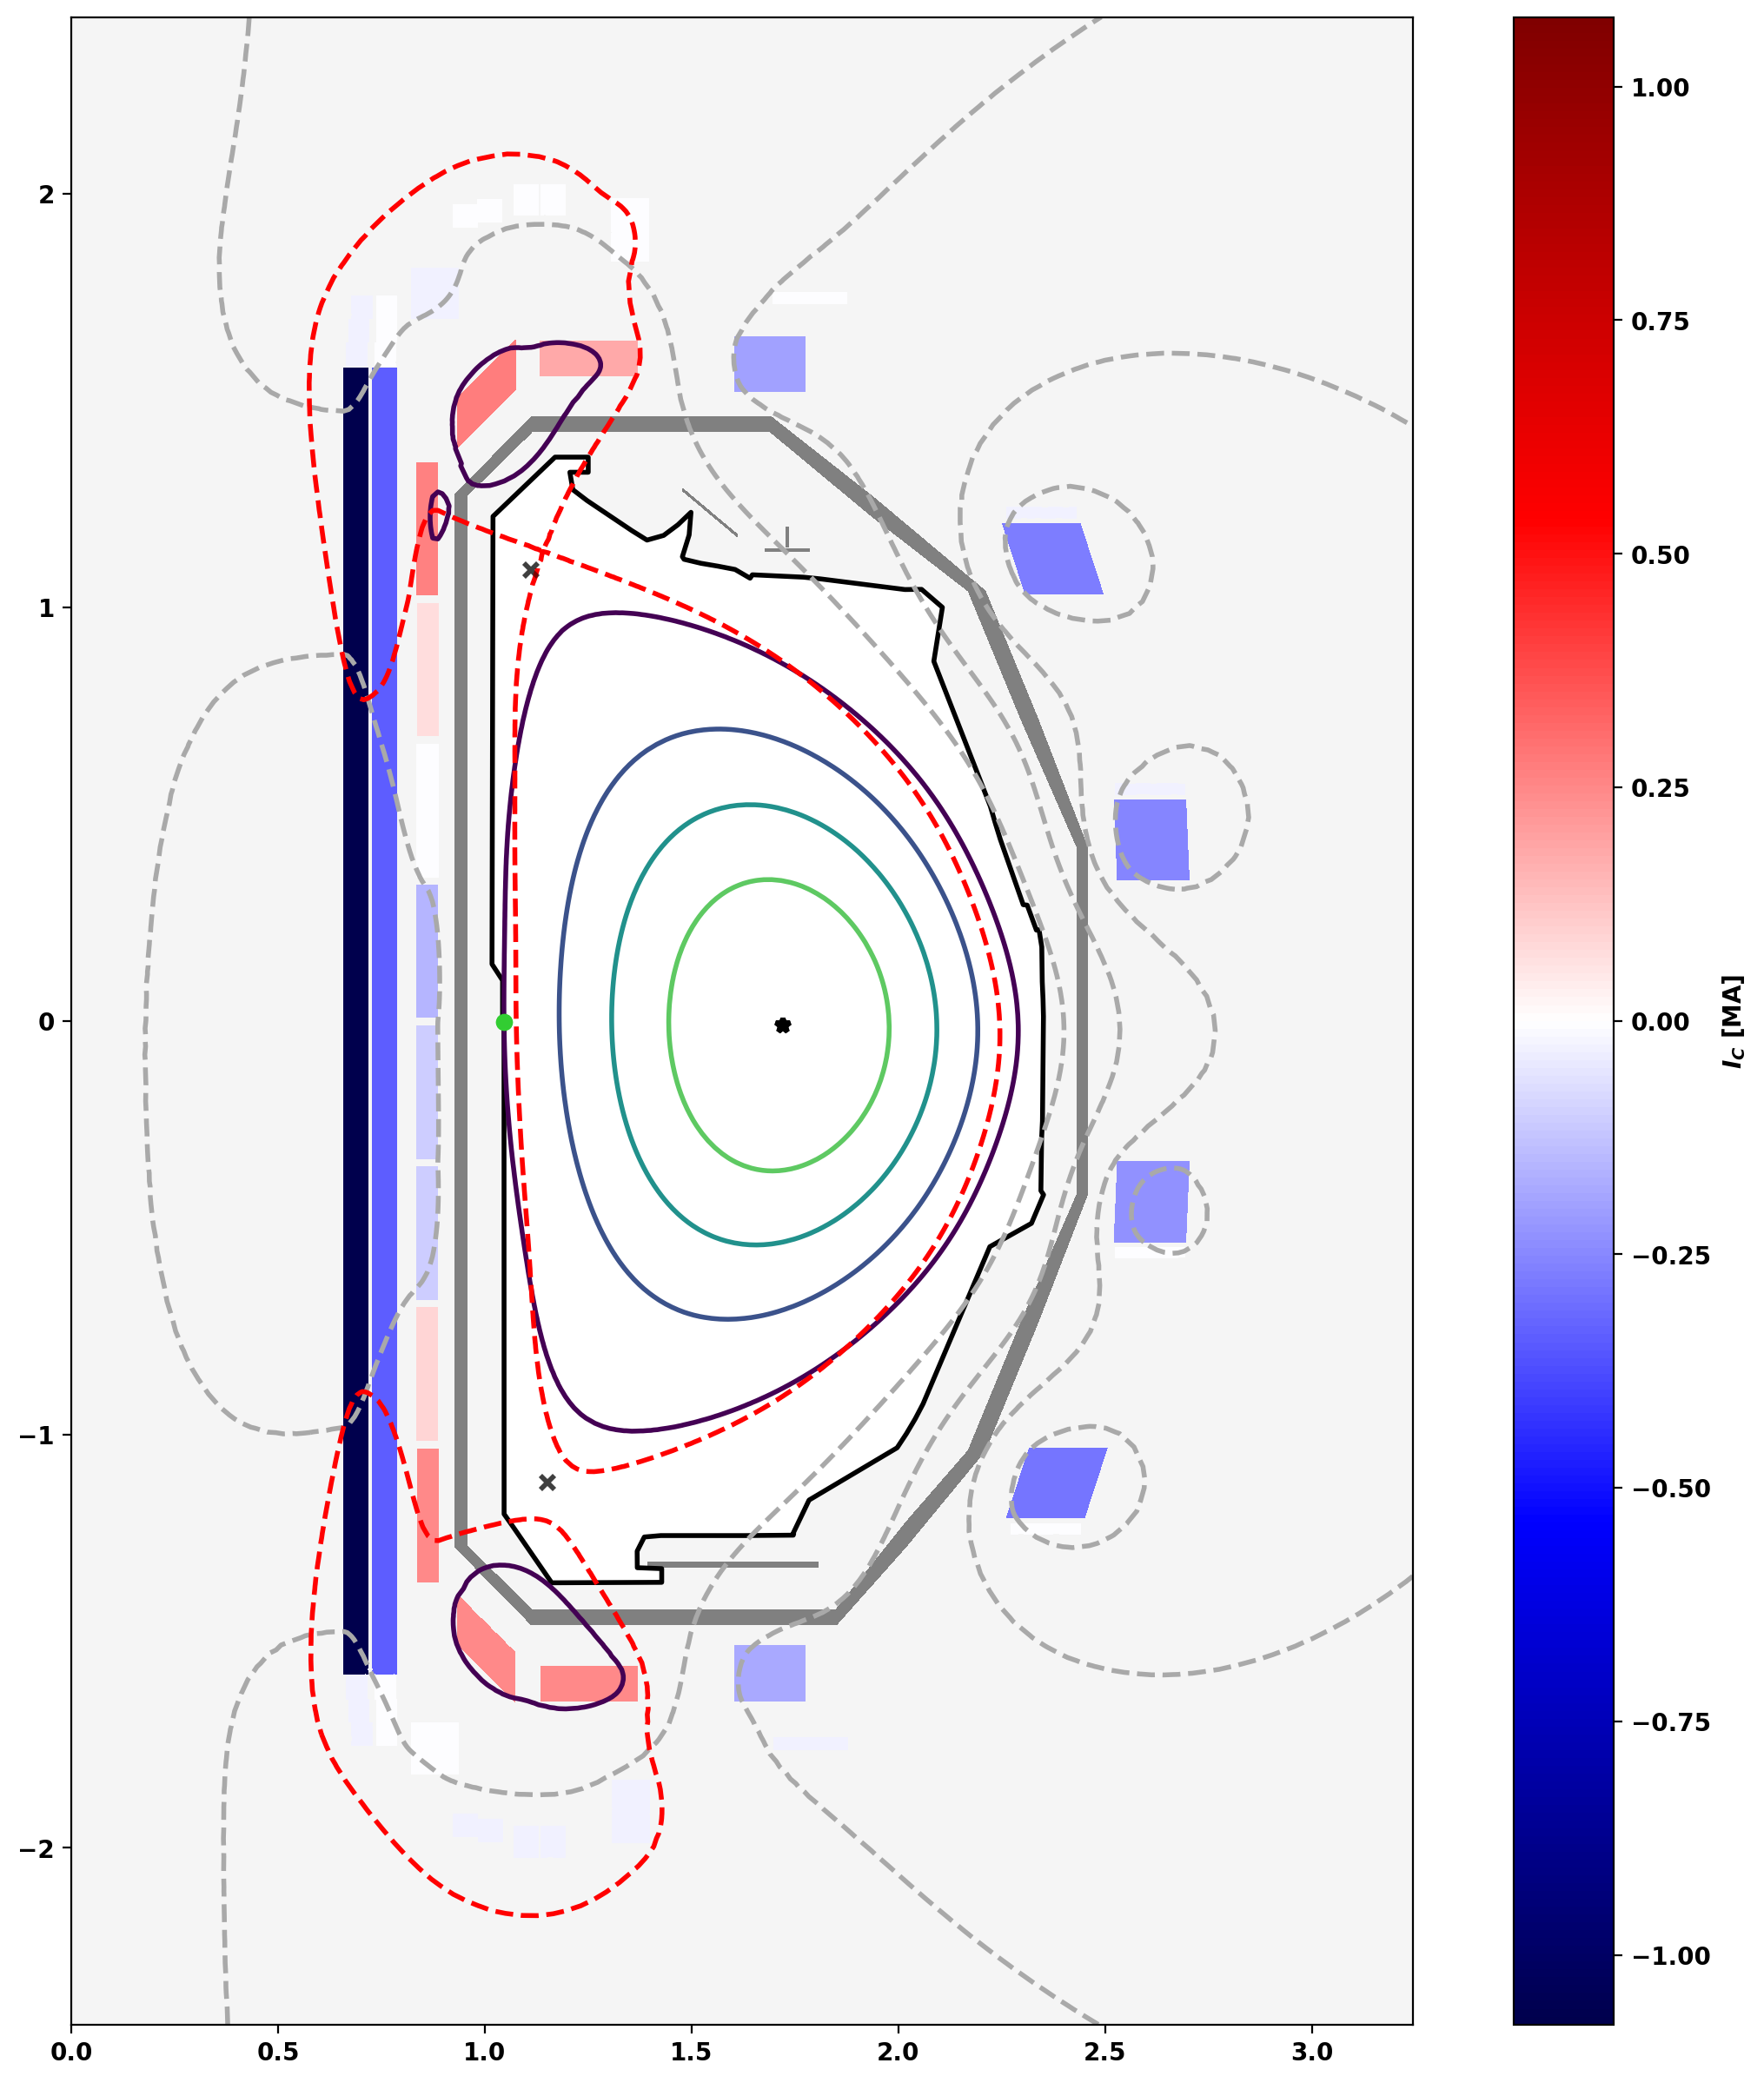

In [ ]:
# Plot Psi
fig, ax = plt.subplots(1,1, figsize=(15,15))
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_psi(fig,ax,psi=psi_eq,plasma_levels=[1.0,],plasma_color='red',vacuum_nlevels=0,plasma_linestyles='dashed')

strike_pts_r = [sp[0] for sp in strike_pts]
strike_pts_z = [sp[1] for sp in strike_pts]
ax.scatter(strike_pts_r, strike_pts_z, color='limegreen', zorder=10)

for i, r in enumerate(strike_pts_r):
    if strike_pts_z[i] > 0:
        print(r)

print(strike_pts_r)
plt.show()